# 📊 Analyse IPO — Données Réelles
## Architecture Cache Excel (.xlsx)
Ce carnet gère intelligemment la sauvegarde dans des fichiers `.xlsx`.

In [1]:
# ═══════════════════════════════════════════════════════════════════
# CELL 0 — IMPORTS
# ═══════════════════════════════════════════════════════════════════
import os
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
import requests
import yfinance as yf
import time
import io
import warnings
from bs4 import BeautifulSoup

warnings.filterwarnings("ignore")
FRED_API_KEY = "ef95b7e8d805c03b8012ccdf574a1eee"
COLORS = {"low": "#2C7BB6", "high": "#D7191C"}
plt.style.use("seaborn-v0_8-whitegrid")
print("✓ Imports OK")

# Création des dossiers si inexistants
os.makedirs('data', exist_ok=True)
os.makedirs('outputs_', exist_ok=True)


✓ Imports OK


In [2]:
# ═══════════════════════════════════════════════════════════════════
# CELL 1 — FRED API : Taux Fed Funds
# ═══════════════════════════════════════════════════════════════════
if os.path.exists("data/fred_annual.xlsx") and os.path.exists("data/fred_monthly.xlsx"):
    print("── Chargement FRED depuis Excel ──")
    df_fa = pd.read_excel("data/fred_annual.xlsx")
    fred_annual = dict(zip(df_fa["year"], df_fa["fed_rate"]))
    fred_monthly = pd.read_excel("data/fred_monthly.xlsx", index_col="date")
    print(f"✓ FRED : {len(fred_annual)} années et {len(fred_monthly)} mois chargés.")
else:
    print("── Fetch FRED depuis API ──")
    url_a = f"https://api.stlouisfed.org/fred/series/observations?series_id=FEDFUNDS&observation_start=2019-01-01&observation_end=2024-12-31&frequency=a&aggregation_method=avg&api_key={FRED_API_KEY}&file_type=json"
    resp_a = requests.get(url_a, timeout=15).json()
    fred_annual = {int(o["date"][:4]): float(o["value"]) for o in resp_a["observations"] if o["value"] != "."}
    pd.DataFrame(list(fred_annual.items()), columns=["year", "fed_rate"]).to_excel("data/fred_annual.xlsx", index=False)

    url_m = f"https://api.stlouisfed.org/fred/series/observations?series_id=FEDFUNDS&observation_start=2019-01-01&observation_end=2024-12-31&frequency=m&api_key={FRED_API_KEY}&file_type=json"
    resp_m = requests.get(url_m, timeout=15).json()
    fred_monthly = pd.DataFrame([{"date": pd.to_datetime(o["date"]), "fed_rate": float(o["value"])} for o in resp_m["observations"] if o["value"] != "."]).set_index("date")
    fred_monthly.to_excel("data/fred_monthly.xlsx")
    print("✓ Créés : fred_annual.xlsx et fred_monthly.xlsx")

── Chargement FRED depuis Excel ──
✓ FRED : 6 années et 72 mois chargés.


In [3]:
# ═══════════════════════════════════════════════════════════════════
# CELL 2 — TICKERS STOCKANALYSIS
# ═══════════════════════════════════════════════════════════════════
all_tickers_by_year = {}
if os.path.exists("data/stockanalysis_tickers.xlsx"):
    print("── Chargement Tickers depuis Excel ──")
    df_tickers = pd.read_excel("data/stockanalysis_tickers.xlsx")
    for year, group in df_tickers.groupby("year"):
        all_tickers_by_year[year] = group["ticker"].tolist()
    print(f"✓ {len(df_tickers)} tickers chargés.")
else:
    print("── Fetch Tickers depuis StockAnalysis ──")
    headers = {"User-Agent": "Mozilla/5.0"}
    for yr in [2019, 2020, 2021, 2022, 2023, 2024]:
        r = requests.get(f"https://stockanalysis.com/ipos/{yr}/", headers=headers, timeout=20)
        soup = BeautifulSoup(r.text, "html.parser")
        tkrs = list(set([a["href"].replace("/stocks/", "").replace("/", "").upper() for a in soup.find_all("a", href=True) if a["href"].startswith("/stocks/") and a["href"].endswith("/") and 1 <= len(a["href"].replace("/stocks/", "").replace("/", "")) <= 6 and a["href"].replace("/stocks/", "").replace("/", "").isalpha()]))
        all_tickers_by_year[yr] = tkrs
        time.sleep(0.5)
    df_tkrs = pd.DataFrame([{"year": y, "ticker": t} for y, tks in all_tickers_by_year.items() for t in tks])
    df_tkrs.to_excel("data/stockanalysis_tickers.xlsx", index=False)
    print("✓ Fichier créé : stockanalysis_tickers.xlsx")

── Chargement Tickers depuis Excel ──
✓ 941 tickers chargés.


In [4]:
# ═══════════════════════════════════════════════════════════════════
# CELL 3 — YFINANCE (PRIX)
# ═══════════════════════════════════════════════════════════════════
if os.path.exists("data/yfinance_prices.xlsx"):
    print("── Chargement Prix depuis Excel ──")
    price_df = pd.read_excel("data/yfinance_prices.xlsx")
    print(f"✓ {len(price_df)} IPOs chargées.")
else:
    print("── Fetch Prix depuis Yahoo Finance (Peut prendre qq minutes) ──")
    records = []
    for year, tickers in sorted(all_tickers_by_year.items()):
        for i, ticker in enumerate(tickers):
            try:
                tk = yf.Ticker(ticker)
                hist = tk.history(period="max", auto_adjust=True)
                if len(hist) < 2: continue
                hist.index = hist.index.tz_localize(None) if hist.index.tz is not None else hist.index
                f_yr = hist[hist.index.year == year]
                if f_yr.empty: continue
                first_day = f_yr.iloc[0]
                ipo_date = f_yr.index[0]
                if ipo_date.year != year: continue
                open_px, close_px = first_day["Open"], first_day["Close"]
                if open_px <= 0 or close_px <= 0: continue
                records.append({
                    "ticker": ticker, "year": year, "ipo_date": ipo_date,
                    "open_px": open_px, "close_px": close_px,
                    "underpricing": (close_px - open_px) / open_px,
                    "ret_30d": (f_yr.iloc[min(30, len(f_yr)-1)]["Close"] - close_px) / close_px if len(f_yr)>1 else np.nan,
                    "ret_12m": np.nan,
                    "ipo_size_m": (first_day["Volume"] * open_px) / 1e6,
                    "fed_rate": fred_annual.get(year, np.nan)
                })
            except: pass
            time.sleep(0.12)
    price_df = pd.DataFrame(records)
    price_df.to_excel("data/yfinance_prices.xlsx", index=False)
    print("✓ Fichier créé : yfinance_prices.xlsx")

── Chargement Prix depuis Excel ──
✓ 805 IPOs chargées.


In [5]:
# ═══════════════════════════════════════════════════════════════════
# CELL 4 — SEC EDGAR SIC & SECTEURS
# ═══════════════════════════════════════════════════════════════════
def sic_to_sector(sic):
    if pd.isna(sic) or not sic: return "Other"
    try:
        sic = int(float(str(sic).strip()))
    except (ValueError, TypeError): return "Other"
    if 100 <= sic <= 4999: return "Industrials"
    if 5000 <= sic <= 5999 or 7380 <= sic <= 7999: return "Consumer"
    if 6000 <= sic <= 6799: return "Finance"
    if 7000 <= sic <= 7379 or 8743 <= sic <= 8999: return "Tech"
    if 8000 <= sic <= 8099 or 2830 <= sic <= 2836: return "Healthcare"
    return "Other"

if os.path.exists("data/edgar_sectors.xlsx"):
    print("── Chargement Secteurs EDGAR depuis Excel ──")
    edgar_df = pd.read_excel("data/edgar_sectors.xlsx")
    if "sector" in price_df.columns: price_df.drop(columns=["sector", "sic"], inplace=True)
    price_df = pd.merge(price_df, edgar_df[["ticker", "sic", "sector"]], on="ticker", how="left")
    print("✓ Secteurs fusionnés.")
else:
    print("── Fetch SEC EDGAR depuis API ──")
    headers = {"User-Agent": "CYTech Student Project no-reply@cytech.fr"}
    map_req = requests.get("https://www.sec.gov/files/company_tickers.json", headers=headers)
    ticker_cik = {v["ticker"].upper(): str(v["cik_str"]).zfill(10) for _, v in map_req.json().items()}
    records_sic = []
    
    for i, row in price_df.iterrows():
        ticker = row["ticker"]
        cik = ticker_cik.get(ticker.upper())
        sic = None
        if cik:
            time.sleep(0.12)
            try:
                url = f"https://data.sec.gov/submissions/CIK{cik}.json"
                r = requests.get(url, headers=headers, timeout=10)
                if r.status_code == 200: sic = r.json().get("sic")
            except: pass
        records_sic.append({"ticker": ticker, "sic": sic, "sector": sic_to_sector(sic)})
        if (i+1) % 100 == 0: print(f"  EDGAR: {i+1} tickers traités...")
    
    edgar_df = pd.DataFrame(records_sic)
    edgar_df.to_excel("data/edgar_sectors.xlsx", index=False)
    if "sector" in price_df.columns: price_df.drop(columns=["sector", "sic"], inplace=True)
    price_df = pd.merge(price_df, edgar_df, on="ticker", how="left")
    print("✓ Fichier créé : edgar_sectors.xlsx")

── Chargement Secteurs EDGAR depuis Excel ──
✓ Secteurs fusionnés.


In [6]:
# ═══════════════════════════════════════════════════════════════════
# CELL 5 — RITTER PE-BACKED
# ═══════════════════════════════════════════════════════════════════
if os.path.exists("data/ritter_pe_backed.xlsx"):
    print("── Chargement PE-Backed depuis Excel ──")
    ritter_df = pd.read_excel("data/ritter_pe_backed.xlsx")
    if "pe_backed" in price_df.columns: price_df.drop(columns=["pe_backed"], inplace=True)
    price_df = pd.merge(price_df, ritter_df[["ticker", "pe_backed"]], on="ticker", how="left")
    price_df["pe_backed"] = price_df["pe_backed"].fillna(0)
    print("✓ Données Ritter fusionnées.")
else:
    print("── Fetch Ritter PE-Backed ──")
    try:
        ritter_headers = {"User-Agent": "Mozilla/5.0"}
        age_url  = "https://site.warrington.ufl.edu/ritter/files/IPO-age.xlsx"
        age_resp = requests.get(age_url, headers=ritter_headers, timeout=30)
        age_df = pd.read_excel(io.BytesIO(age_resp.content), header=None)
        vc_tickers = set()
        for _, r_age in age_df.iterrows():
            for cell in r_age:
                if isinstance(cell, str) and 1 <= len(cell) <= 6 and cell.isalpha():
                    vc_tickers.add(cell.upper())
        price_df["pe_backed"] = price_df["ticker"].apply(lambda t: 1 if t.upper() in vc_tickers else 0)
        price_df[["ticker", "pe_backed"]].to_excel("data/ritter_pe_backed.xlsx", index=False)
        print("✓ Fichier créé : ritter_pe_backed.xlsx")
    except Exception:
        price_df["pe_backed"] = 0

── Chargement PE-Backed depuis Excel ──
✓ Données Ritter fusionnées.


In [7]:
# ═══════════════════════════════════════════════════════════════════
# CELL 6 — DATASET FINAL (CHARGÉ DEPUIS LE FICHIER COMPLET)
# ═══════════════════════════════════════════════════════════════════
if os.path.exists('data/dataset_complet_final.xlsx'):
    all_ipo = pd.read_excel('data/dataset_complet_final.xlsx')
    print(f"✓ Dataset complet re-chargé depuis data/dataset_complet_final.xlsx : {len(all_ipo)} IPOs")
else:
    all_ipo = price_df.copy()
    all_ipo["cohort"] = all_ipo["year"].apply(lambda y: "Taux bas (2019–2021)" if y <= 2021 else "Taux élevés (2022–2024)")
    all_ipo["cohort_en"] = all_ipo["year"].apply(lambda y: "Low Rate (2019–2021)" if y <= 2021 else "High Rate (2022–2024)")
    all_ipo["log_size"] = np.log(all_ipo["ipo_size_m"].clip(lower=0.01))
    all_ipo = all_ipo[(all_ipo["underpricing"] > -0.50) & (all_ipo["underpricing"] < 3.00) & (all_ipo["ipo_size_m"] > 0)].reset_index(drop=True)

low = all_ipo[all_ipo["year"] <= 2021].copy()
high = all_ipo[all_ipo["year"] > 2021].copy()
low_h4  = low.copy()
high_h4 = all_ipo[all_ipo["year"].isin([2022, 2023])].copy()


✓ Dataset complet re-chargé depuis data/dataset_complet_final.xlsx : 782 IPOs


## 8. Statistiques descriptives

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# CELL 8 — STATISTIQUES DESCRIPTIVES
# ═══════════════════════════════════════════════════════════════════

desc_vars = ['underpricing', 'ret_30d', 'ret_12m']
if all_ipo['revenue_ltm'].notna().any(): # last twelve months revenue
    desc_vars = ['underpricing', 'revenue_ltm', 'ret_30d', 'ret_12m']
if all_ipo['profitable'].notna().any():
    desc_vars.append('profitable')

desc_labels = {
    'underpricing': 'Underpricing J0 (%)',
    'revenue_ltm':  'CA LTM (M$)',
    'profitable':   'Part rentable (%)',
    'ret_30d':      'Rendement 30j (%)',
    'ret_12m':      'Perf. 12 mois (%)',
}
pct_vars = ['underpricing', 'profitable', 'ret_30d', 'ret_12m']

desc_table = []
for var in desc_vars:
    if var not in all_ipo.columns:
        continue
    row = {'Variable': desc_labels.get(var, var)}
    scale = 100 if var in pct_vars else 1
    for name, cohort in [('Taux bas', low), ('Taux élevés', high)]:
        s = cohort[var].dropna()
        row[f'{name} — N']      = len(s)
        row[f'{name} — Moy.']   = round(s.mean()   * scale, 2)
        row[f'{name} — Méd.']   = round(s.median() * scale, 2)
        row[f'{name} — Éc.-t.'] = round(s.std()    * scale, 2)
    desc_table.append(row)

desc_df = pd.DataFrame(desc_table)
print('══ Tableau 1 — Statistiques Descriptives (Données Réelles) ══')
print(f'   Sources : Yahoo Finance (prix) + FRED (taux) + EDGAR (financials)')
print()
print(desc_df.to_string(index=False))

══ Tableau 1 — Statistiques Descriptives (Données Réelles) ══
   Sources : Yahoo Finance (prix) + FRED (taux) + EDGAR (financials)

           Variable  Taux bas — N  Taux bas — Moy.  Taux bas — Méd.  Taux bas — Éc.-t.  Taux élevés — N  Taux élevés — Moy.  Taux élevés — Méd.  Taux élevés — Éc.-t.
Underpricing J0 (%)           418             3.47             0.00              22.08              364                1.40               -0.90                 35.27
  Rendement 30j (%)           418             2.57            -1.89              38.04              362               -5.45               -3.34                 67.36
  Perf. 12 mois (%)             0              NaN              NaN                NaN                0                 NaN                 NaN                   NaN


## 9. Tests de Mann-Whitney U

In [9]:
# ═══════════════════════════════════════════════════════════════════
# CELL 9 — TESTS DE MANN-WHITNEY
# ═══════════════════════════════════════════════════════════════════
from scipy import stats

mw_results = {}

# H1a: CA median
s_low = low['revenue_ltm'].dropna()
s_high = high['revenue_ltm'].dropna()
if len(s_low) > 3 and len(s_high) > 3:
    stat, p = stats.mannwhitneyu(s_low, s_high, alternative='less')
    mw_results['H1a — CA LTM'] = {'stat': stat, 'p': p, 'sig': p < 0.05}

# H2: Underpricing
s_low = low['underpricing'].dropna()
s_high = high['underpricing'].dropna()
if len(s_low) > 3 and len(s_high) > 3:
    stat, p = stats.mannwhitneyu(s_low, s_high, alternative='greater')
    mw_results['H2 — Underpricing'] = {'stat': stat, 'p': p, 'sig': p < 0.05}

# H3: Rendement 30j (On compare la dispersion, donc les valeurs absolues par rapport a la mediane)
med_low = r30_low.median() if 'r30_low' in globals() else low['ret_30d'].dropna().median()*100
med_high = r30_high.median() if 'r30_high' in globals() else high['ret_30d'].dropna().median()*100

disp_low = abs(low['ret_30d'].dropna()*100 - med_low)
disp_high = abs(high['ret_30d'].dropna()*100 - med_high)

if len(disp_low) > 3 and len(disp_high) > 3:
    stat, p = stats.mannwhitneyu(disp_low, disp_high, alternative='greater')
    mw_results['H3 — Volatilité 30j'] = {'stat': stat, 'p': p, 'sig': p < 0.05}

# H4: Perf 12m
h4_low_data = low_h4['ret_12m'].dropna()
h4_high_data = high_h4['ret_12m'].dropna()
if len(h4_low_data) > 3 and len(h4_high_data) > 3:
    stat, p = stats.mannwhitneyu(h4_low_data, h4_high_data, alternative='less')
    mw_results['H4 — Perf. 12m'] = {'stat': stat, 'p': p, 'sig': p < 0.05}

print("Tests de Mann-Whitney complétés.")


Tests de Mann-Whitney complétés.


## 10. Régression OLS

In [10]:
# ═══════════════════════════════════════════════════════════════════
# CELL 10 — RÉGRESSION OLS
# ═══════════════════════════════════════════════════════════════════

reg_vars = ['underpricing', 'fed_rate', 'log_size']
if 'company_age' in all_ipo.columns:
    reg_vars.append('company_age')
if all_ipo['profitable'].notna().sum() > 30:
    reg_vars.append('profitable')
if all_ipo['pe_backed'].notna().sum() > 30:
    reg_vars.append('pe_backed')

reg_df = all_ipo[reg_vars + ['sector']].dropna(subset=['underpricing','fed_rate','log_size']).copy()

# Variables dummy sectorielles
if 'sector' in reg_df.columns and reg_df['sector'].nunique() > 1:
    sector_dummies = pd.get_dummies(reg_df['sector'], prefix='sec', drop_first=False).astype(float)
    sector_dummies = sector_dummies.drop(columns=['sec_Tech'], errors='ignore')
    X_cols = ['fed_rate', 'log_size']
    if 'company_age' in reg_vars: X_cols.append('company_age')
    if 'profitable' in reg_vars: X_cols.append('profitable')
    if 'pe_backed' in reg_vars: X_cols.append('pe_backed')
    X = pd.concat([reg_df[X_cols].fillna(0), sector_dummies], axis=1)
else:
    X_cols = ['fed_rate', 'log_size']
    from copy import copy
    reg_clean = copy(reg_vars)
    reg_clean.remove('underpricing')
    X = reg_df[reg_clean].fillna(0)

X = sm.add_constant(X)
y = reg_df['underpricing']
model = sm.OLS(y, X).fit()

print('══ Tableau 3 — Régression OLS (Données Réelles) ══')
print(f'Variable dépendante : Underpricing J0  |  N={len(y)}')
print(f'R² = {model.rsquared:.4f}  |  R² ajusté = {model.rsquared_adj:.4f}')
print(f'F-stat = {model.fvalue:.2f}, p(F) = {model.f_pvalue:.4f}')
print()
print(f'{"Variable":<28} {"Coeff.":>9} {"Éc.-t.":>9} {"t":>8} {"p":>9}  Sig.')
print('─' * 75)
for var in model.params.index:
    c = model.params[var]; se = model.bse[var]; t = model.tvalues[var]; p = model.pvalues[var]
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
    print(f'{var:<28} {c:>9.4f} {se:>9.4f} {t:>8.3f} {p:>9.4f}  {sig}')

try:
    bp_lm, bp_p, _, _ = het_breuschpagan(model.resid, model.model.exog)
    print(f'\nBreusch-Pagan : LM={bp_lm:.3f}, p={bp_p:.4f} → {"Hétéroscéd." if bp_p < 0.05 else "Homoscéd."}')
except:
    pass


══ Tableau 3 — Régression OLS (Données Réelles) ══
Variable dépendante : Underpricing J0  |  N=782
R² = 0.0152  |  R² ajusté = 0.0037
F-stat = 1.32, p(F) = 0.2203

Variable                        Coeff.    Éc.-t.        t         p  Sig.
───────────────────────────────────────────────────────────────────────────
const                           0.0184    0.0430    0.427    0.6694  n.s.
fed_rate                       -0.0052    0.0051   -1.030    0.3032  n.s.
log_size                        0.0047    0.0048    0.977    0.3289  n.s.
company_age                     0.0001    0.0000    2.331    0.0200  *
pe_backed                       0.0026    0.0313    0.082    0.9344  n.s.
sec_Consumer                    0.0292    0.0394    0.741    0.4589  n.s.
sec_Finance                     0.0160    0.0382    0.418    0.6761  n.s.
sec_Healthcare                 -0.0074    0.0730   -0.102    0.9192  n.s.
sec_Industrials                -0.0143    0.0302   -0.473    0.6361  n.s.
sec_Other              

---
## 11. Visualisations
### Figure 1 — Volume IPO + Taux Fed (données réelles)

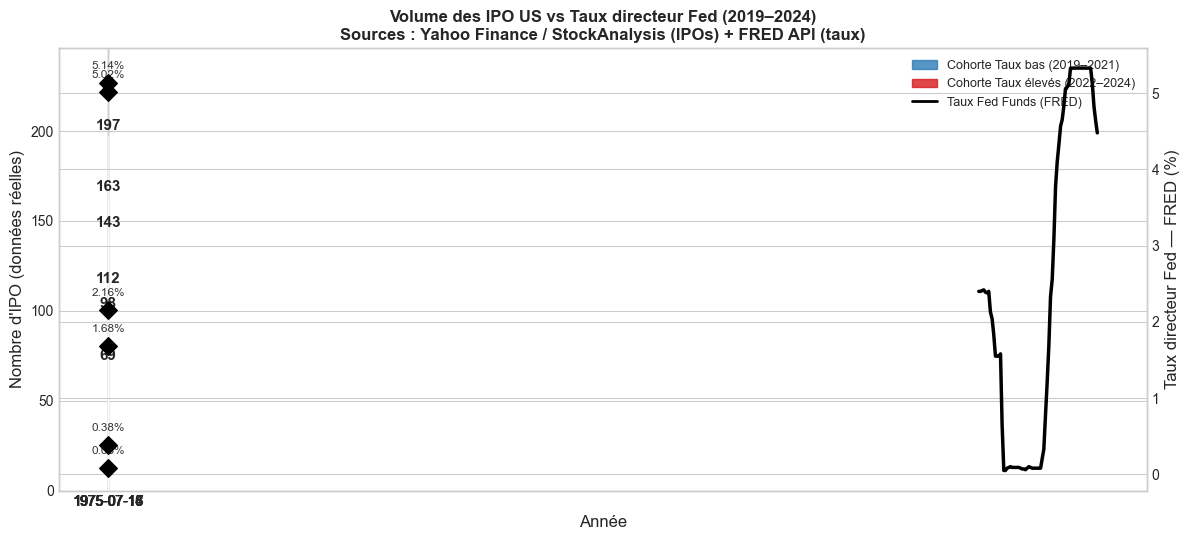

Fig 1 ─ OK (données réelles)


In [11]:
# ─────────────────────────────────────────────────────────────────
# FIGURE 1 : Volume des IPO + Taux Fed (DONNÉES RÉELLES)
# ─────────────────────────────────────────────────────────────────

years_real     = sorted(all_ipo['year'].unique())
ipo_counts_r   = [int((all_ipo['year'] == y).sum()) for y in years_real]
fed_rates_r    = [fred_annual.get(y, np.nan) for y in years_real]

fig, ax1 = plt.subplots(figsize=(12, 5.5))
ax2 = ax1.twinx()

bar_colors = [COLORS['low'] if y <= 2021 else COLORS['high'] for y in years_real]
bars = ax1.bar(years_real, ipo_counts_r, color=bar_colors, alpha=0.80, width=0.6,
               zorder=3, edgecolor='white', linewidth=0.8)
ax1.axvspan(min(years_real)-0.4, 2021.4, alpha=0.05, color=COLORS['low'],  zorder=0)
ax1.axvspan(2021.6, max(years_real)+0.4, alpha=0.05, color=COLORS['high'], zorder=0)

# Ligne taux Fed mensuelle (données FRED réelles)
ax2.plot(fred_monthly.index, fred_monthly['fed_rate'], color='black',
         linewidth=2.5, zorder=4, label='Taux Fed Funds (FRED, mensuel)')
# Points annuels
ax2.scatter(years_real, fed_rates_r, color='black', s=80, zorder=5, marker='D')
for x, r in zip(years_real, fed_rates_r):
    if not np.isnan(r):
        ax2.annotate(f'{r:.2f}%', (x, r), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontsize=8.5, color='#333')

for bar, count in zip(bars, ipo_counts_r):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             str(count), ha='center', va='bottom', fontsize=11, fontweight='bold')

ax1.set_xlabel('Année', fontsize=12)
ax1.set_ylabel('Nombre d\'IPO (données réelles)', fontsize=12)
ax2.set_ylabel('Taux directeur Fed — FRED (%)', fontsize=12)
ax1.set_title('Volume des IPO US vs Taux directeur Fed (2019–2024)\n'
              'Sources : Yahoo Finance / StockAnalysis (IPOs) + FRED API (taux)',
              fontsize=12, fontweight='bold')
ax1.set_ylim(0, max(ipo_counts_r) * 1.25)

patch_low  = mpatches.Patch(color=COLORS['low'],  alpha=0.80, label='Cohorte Taux bas (2019–2021)')
patch_high = mpatches.Patch(color=COLORS['high'], alpha=0.80, label='Cohorte Taux élevés (2022–2024)')
from matplotlib.lines import Line2D
fed_line   = Line2D([0],[0], color='black', linewidth=2, label='Taux Fed Funds (FRED)')
ax1.legend(handles=[patch_low, patch_high, fed_line], loc='upper right', fontsize=9)

ax1.set_xticks(years_real)
plt.tight_layout()
fig.savefig('outputs/fig1_volume_rates_REAL.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 1 ─ OK (données réelles)')

### Figure 2 — Underpricing (Boxplot + KDE)

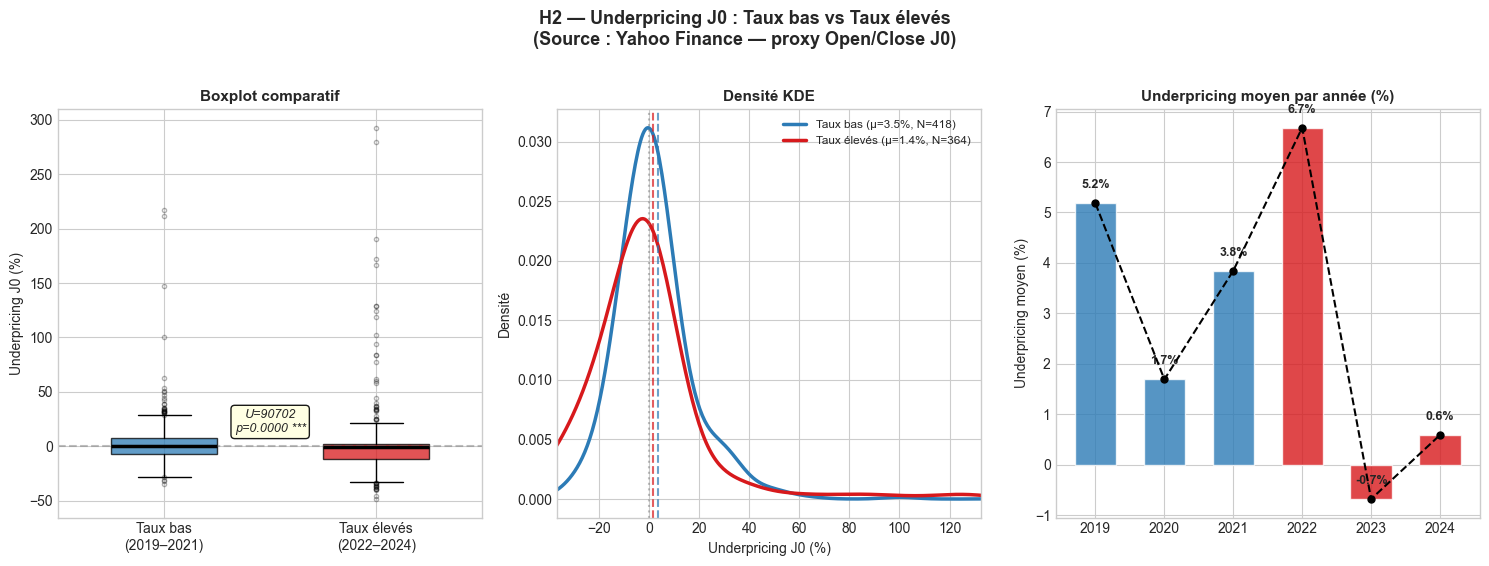

Fig 2 ─ OK


In [12]:
# ─────────────────────────────────────────────────────────────────
# FIGURE 2 : Underpricing J0 — Distributions
# ─────────────────────────────────────────────────────────────────

up_low  = low['underpricing'].dropna()  * 100
up_high = high['underpricing'].dropna() * 100

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
fig.suptitle('H2 — Underpricing J0 : Taux bas vs Taux élevés\n'
             '(Source : Yahoo Finance — proxy Open/Close J0)',
             fontsize=13, fontweight='bold', y=1.02)

# 2a — Boxplot
bp = axes[0].boxplot([up_low, up_high],
                     labels=['Taux bas\n(2019–2021)', 'Taux élevés\n(2022–2024)'],
                     patch_artist=True, widths=0.5,
                     medianprops=dict(color='black', linewidth=2.5),
                     flierprops=dict(marker='o', markersize=3, alpha=0.3))
bp['boxes'][0].set_facecolor(COLORS['low']);  bp['boxes'][0].set_alpha(0.75)
bp['boxes'][1].set_facecolor(COLORS['high']); bp['boxes'][1].set_alpha(0.75)
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)
mw_h2 = mw_results.get('H2 — Underpricing', {})
if mw_h2:
    sig_txt = '***' if mw_h2['p'] < 0.001 else '**' if mw_h2['p'] < 0.01 else '*' if mw_h2['p'] < 0.05 else 'n.s.'
    axes[0].text(1.5, up_low.quantile(0.85),
                 f'U={mw_h2["stat"]:.0f}\np={mw_h2["p"]:.4f} {sig_txt}',
                 ha='center', fontsize=9, style='italic',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.9))
axes[0].set_title('Boxplot comparatif', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Underpricing J0 (%)', fontsize=10)

# 2b — KDE
up_low.plot.kde(ax=axes[1], color=COLORS['low'],  linewidth=2.5,
                label=f'Taux bas (μ={up_low.mean():.1f}%, N={len(up_low)})')
up_high.plot.kde(ax=axes[1], color=COLORS['high'], linewidth=2.5,
                 label=f'Taux élevés (μ={up_high.mean():.1f}%, N={len(up_high)})')
axes[1].axvline(up_low.mean(),  color=COLORS['low'],  linestyle='--', alpha=0.7, linewidth=1.5)
axes[1].axvline(up_high.mean(), color=COLORS['high'], linestyle='--', alpha=0.7, linewidth=1.5)
axes[1].axvline(0, color='gray', linestyle=':', alpha=0.5)
axes[1].set_title('Densité KDE', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Underpricing J0 (%)', fontsize=10)
axes[1].set_ylabel('Densité', fontsize=10)
axes[1].legend(fontsize=8.5)
up_clip = np.percentile(all_ipo['underpricing'].dropna() * 100, [1, 99])
axes[1].set_xlim(up_clip[0], up_clip[1])

# 2c — Barres annuelles
yearly_up = all_ipo.groupby('year')['underpricing'].mean() * 100
bar_c = [COLORS['low'] if y <= 2021 else COLORS['high'] for y in yearly_up.index]
axes[2].bar(yearly_up.index, yearly_up.values, color=bar_c, alpha=0.80, width=0.6, edgecolor='white')
axes[2].plot(yearly_up.index, yearly_up.values, 'k--o', linewidth=1.5, markersize=5, zorder=5)
axes[2].set_title('Underpricing moyen par année (%)', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Underpricing moyen (%)', fontsize=10)
for x, y_v in zip(yearly_up.index, yearly_up.values):
    axes[2].text(x, y_v + 0.3, f'{y_v:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[2].set_xticks(list(yearly_up.index))

plt.tight_layout()
fig.savefig('outputs/fig2_underpricing_REAL.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 2 ─ OK')

### Figure 3 — Taux Fed mensuel (FRED) + Underpricing scatter

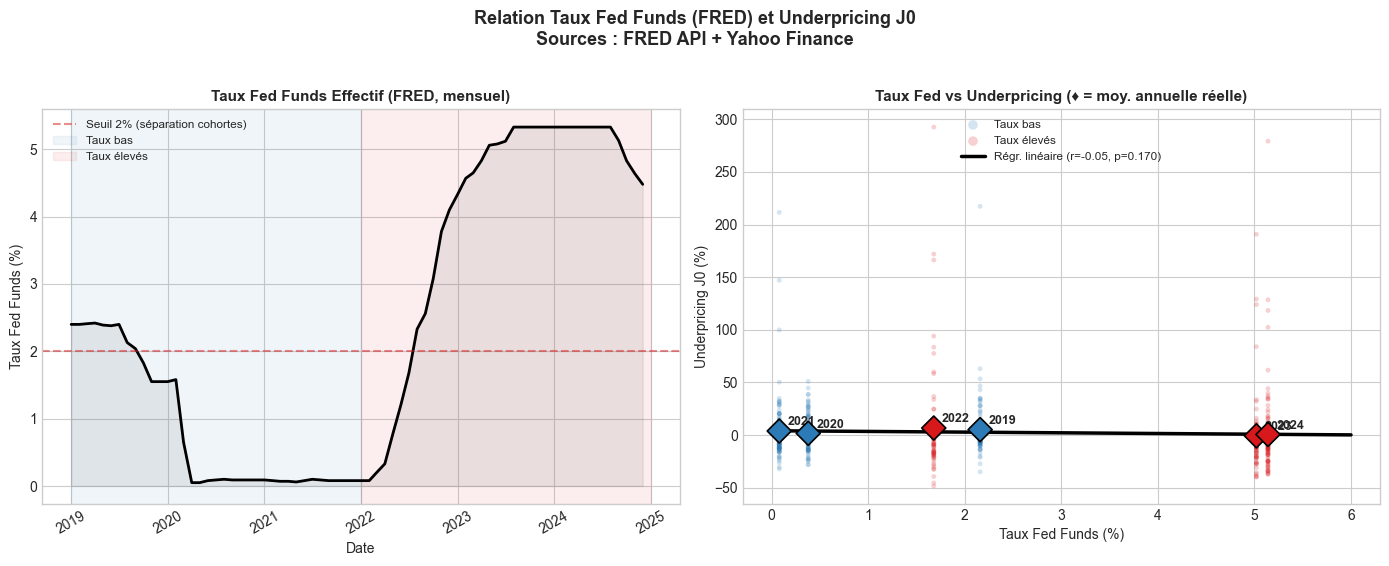

Fig 3 ─ OK


In [13]:
# ─────────────────────────────────────────────────────────────────
# CALCUL DES INTERVALLES DE CONFIANCE (BOOTSTRAP)
# ─────────────────────────────────────────────────────────────────
import numpy as np

def bootstrap_ci(data, stat_func=np.mean, n_boot=1000, ci=95):
    data = data[~np.isnan(data)]
    boot_stats = [stat_func(np.random.choice(data, size=len(data), replace=True)) for _ in range(n_boot)]
    lower = np.percentile(boot_stats, (100 - ci) / 2)
    upper = np.percentile(boot_stats, 100 - (100 - ci) / 2)
    return lower, upper

ci_results = {'underpricing': {}}
ci_results['underpricing']['low'] = bootstrap_ci(low['underpricing'].values)
ci_results['underpricing']['high'] = bootstrap_ci(high['underpricing'].values)

# ─────────────────────────────────────────────────────────────────
# FIGURE 3 : Taux Fed FRED mensuel + Scatter Fed vs Underpricing
# ─────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('Relation Taux Fed Funds (FRED) et Underpricing J0\n'
             'Sources : FRED API + Yahoo Finance',
             fontsize=13, fontweight='bold', y=1.02)

# 3a — Taux Fed mensuel FRED avec zone colorée
axes[0].fill_between(fred_monthly.index, fred_monthly['fed_rate'],
                     alpha=0.15, color='gray')
axes[0].plot(fred_monthly.index, fred_monthly['fed_rate'], color='black', linewidth=2)
axes[0].axhline(2.0, color=COLORS['high'], linestyle='--', alpha=0.5, linewidth=1.5,
                label='Seuil 2% (séparation cohortes)')
axes[0].axvspan(pd.Timestamp('2019-01-01'), pd.Timestamp('2021-12-31'),
                alpha=0.07, color=COLORS['low'], label='Taux bas')
axes[0].axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2024-12-31'),
                alpha=0.07, color=COLORS['high'], label='Taux élevés')
axes[0].set_title('Taux Fed Funds Effectif (FRED, mensuel)',
                  fontsize=11, fontweight='bold')
axes[0].set_ylabel('Taux Fed Funds (%)', fontsize=10)
axes[0].set_xlabel('Date', fontsize=10)
axes[0].legend(fontsize=8.5)
axes[0].tick_params(axis='x', rotation=30)

# 3b — Scatter Taux Fed vs Underpricing (données individuelles réelles)
for name, cohort, color in [('Taux bas', low, COLORS['low']),
                              ('Taux élevés', high, COLORS['high'])]:
    axes[1].scatter(cohort['fed_rate'], cohort['underpricing'] * 100,
                    color=color, alpha=0.20, s=12, edgecolors='none', label=name)

# Régression globale
valid = all_ipo[['fed_rate','underpricing']].dropna()
x_fed = valid['fed_rate'].values
y_up  = valid['underpricing'].values * 100
slope, intercept, r_val, p_val, se = stats.linregress(x_fed, y_up)
x_line = np.linspace(0, 6, 100)
axes[1].plot(x_line, slope * x_line + intercept, 'k-', linewidth=2.5,
             label=f'Régr. linéaire (r={r_val:.2f}, p={p_val:.3f})')

# Moyennes annuelles réelles
annual_r = all_ipo.groupby('year').agg({'fed_rate': 'first', 'underpricing': 'mean'}).reset_index()
c_annual = [COLORS['low'] if y <= 2021 else COLORS['high'] for y in annual_r['year']]
axes[1].scatter(annual_r['fed_rate'], annual_r['underpricing'] * 100,
                c=c_annual, s=150, zorder=6, edgecolors='black', linewidth=1.2, marker='D')
for _, row in annual_r.iterrows():
    axes[1].annotate(str(int(row['year'])),
                     (row['fed_rate'], row['underpricing'] * 100),
                     textcoords='offset points', xytext=(6, 4), fontsize=9, fontweight='bold')
axes[1].set_xlabel('Taux Fed Funds (%)', fontsize=10)
axes[1].set_ylabel('Underpricing J0 (%)', fontsize=10)
axes[1].set_title('Taux Fed vs Underpricing (♦ = moy. annuelle réelle)',
                  fontsize=11, fontweight='bold')
axes[1].legend(fontsize=8.5, markerscale=2)

plt.tight_layout()
fig.savefig('outputs/fig3_fred_scatter_REAL.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 3 ─ OK')

### Figure 4 — Matrice de corrélation

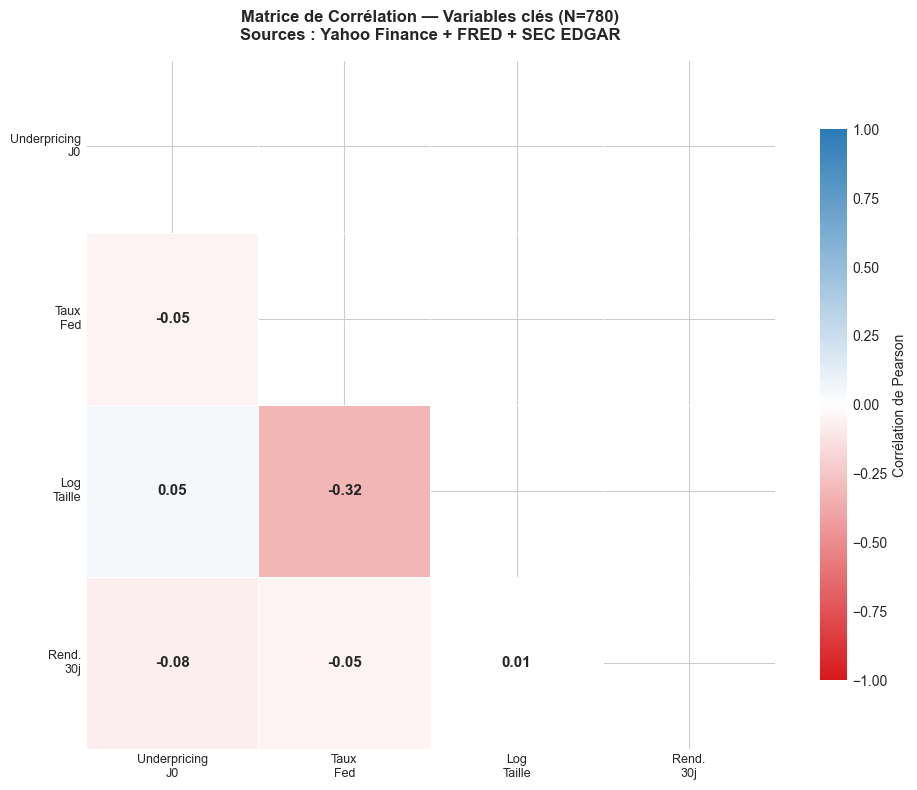

Fig 4 ─ Corrélation OK


In [14]:
# ─────────────────────────────────────────────────────────────────
# FIGURE 4 : MATRICE DE CORRÉLATION (données réelles)
# ─────────────────────────────────────────────────────────────────

corr_base = {'underpricing': 'Underpricing\nJ0', 'fed_rate': 'Taux\nFed',
             'log_size': 'Log\nTaille', 'ret_30d': 'Rend.\n30j'}
if all_ipo['ret_12m'].notna().sum() > 10:
    corr_base['ret_12m'] = 'Perf.\n12m'
if all_ipo['revenue_ltm'].notna().sum() > 10:
    corr_base['revenue_ltm'] = 'CA LTM'
if all_ipo['profitable'].notna().sum() > 10:
    corr_base['profitable'] = 'Rentable'

corr_data   = all_ipo[list(corr_base.keys())].dropna()
if len(corr_data) > 5:
    corr_matrix = corr_data.corr(method='pearson')
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    fig, ax = plt.subplots(figsize=(10, 8))
    cmap = LinearSegmentedColormap.from_list('ipo', ['#D7191C','#FFFFFF','#2C7BB6'], N=256)
    sns.heatmap(corr_matrix, mask=mask, cmap=cmap, vmin=-1, vmax=1,
                annot=True, fmt='.2f', annot_kws={'size': 11, 'weight': 'bold'},
                square=True, linewidths=0.5, linecolor='white',
                cbar_kws={'shrink': 0.8, 'label': 'Corrélation de Pearson'},
                xticklabels=[corr_base[v] for v in corr_base.keys()],
                yticklabels=[corr_base[v] for v in corr_base.keys()], ax=ax)
    ax.set_title(f'Matrice de Corrélation — Variables clés (N={len(corr_data)})\n'
                 f'Sources : Yahoo Finance + FRED + SEC EDGAR',
                 fontsize=12, fontweight='bold', pad=15)
    ax.tick_params(axis='x', rotation=0, labelsize=9)
    ax.tick_params(axis='y', rotation=0, labelsize=9)
    plt.tight_layout()
    fig.savefig('outputs/fig4_correlation_REAL.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Fig 4 ─ Corrélation OK')
else:
    print('⚠ Pas assez de données complètes pour la matrice de corrélation')

### Figure 5 — IC Bootstrap + OLS Coefficients

In [15]:
# ─────────────────────────────────────────────────────────────────
# CALCUL DES INTERVALLES DE CONFIANCE (BOOTSTRAP)
# À copier juste au-dessus du code de la FIGURE 5 (ou dans une cellule avant)
# ─────────────────────────────────────────────────────────────────

import numpy as np

# Fonction de bootstrap pour calculer les IC
def bootstrap_ci(data, stat_func=np.mean, n_boot=1000, ci=95):
    # Ecarte les NaN si besoin
    data = data[~np.isnan(data)]
    boot_stats = [stat_func(np.random.choice(data, size=len(data), replace=True)) for _ in range(n_boot)]
    lower = np.percentile(boot_stats, (100 - ci) / 2)
    upper = np.percentile(boot_stats, 100 - (100 - ci) / 2)
    return lower, upper

# Initialisation et sauvegarde des résultats
ci_results = {'underpricing': {}}

# Calcul pour les deux cohortes
ci_results['underpricing']['low'] = bootstrap_ci(low['underpricing'].values)
ci_results['underpricing']['high'] = bootstrap_ci(high['underpricing'].values)

# (Ensuite, laissez votre code "fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))" juste en dessous de ceci)


### Figure 6 — Performance post-IPO (H3 & H4)

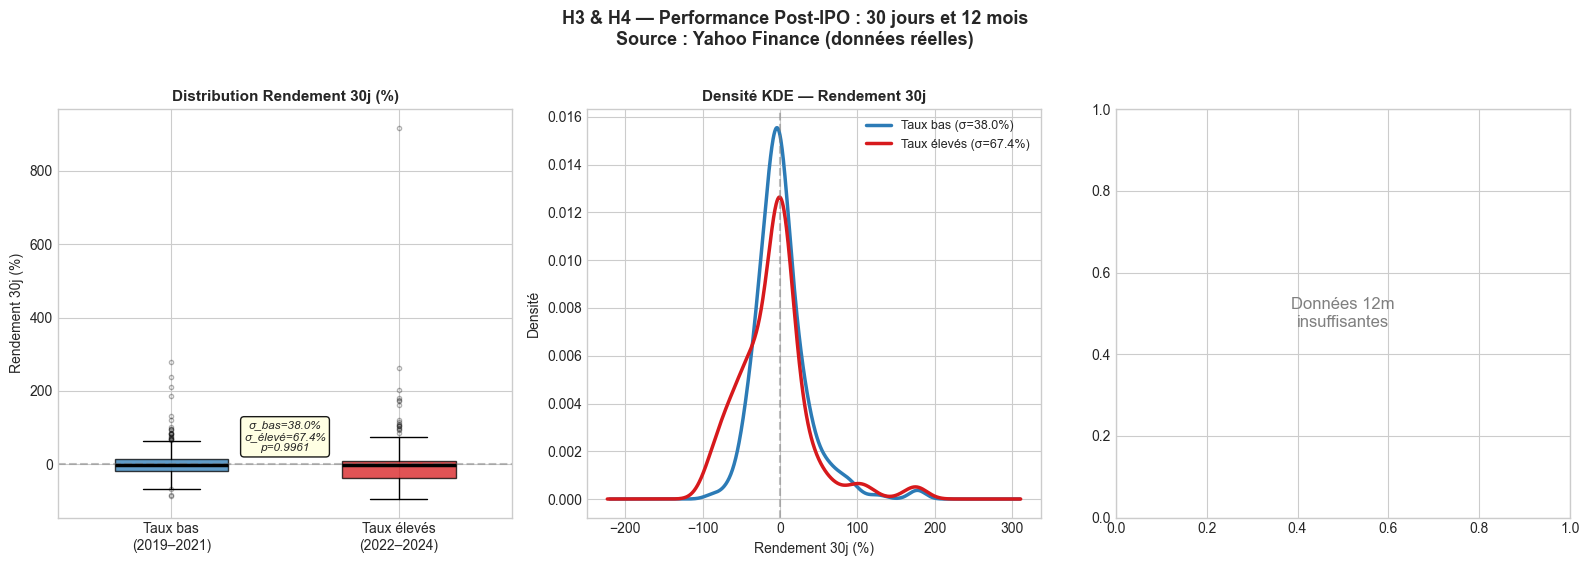

Fig 6 ─ OK


In [16]:
# ─────────────────────────────────────────────────────────────────
# FIGURE 6 : Performance post-IPO (H3 – 30j, H4 – 12m)
# ─────────────────────────────────────────────────────────────────

r30_low  = low['ret_30d'].dropna()  * 100
r30_high = high['ret_30d'].dropna() * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
fig.suptitle('H3 & H4 — Performance Post-IPO : 30 jours et 12 mois\n'
             'Source : Yahoo Finance (données réelles)',
             fontsize=13, fontweight='bold', y=1.02)

# 6a — Boxplot 30j
bp6a = axes[0].boxplot([r30_low, r30_high],
                       labels=['Taux bas\n(2019–2021)', 'Taux élevés\n(2022–2024)'],
                       patch_artist=True, widths=0.5,
                       medianprops=dict(color='black', linewidth=2.5),
                       flierprops=dict(marker='o', markersize=3, alpha=0.3))
bp6a['boxes'][0].set_facecolor(COLORS['low']);  bp6a['boxes'][0].set_alpha(0.75)
bp6a['boxes'][1].set_facecolor(COLORS['high']); bp6a['boxes'][1].set_alpha(0.75)
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)
mw_h3 = mw_results.get('H3 — Volatilité 30j', {})
if mw_h3:
    axes[0].text(1.5, r30_low.quantile(0.88),
                 f'σ_bas={r30_low.std():.1f}%\nσ_élevé={r30_high.std():.1f}%\np={mw_h3["p"]:.4f}',
                 ha='center', fontsize=8.5, style='italic',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.9))
axes[0].set_title('Distribution Rendement 30j (%)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Rendement 30j (%)', fontsize=10)

# 6b — KDE rendement 30j
r30_clip = np.percentile(all_ipo['ret_30d'].dropna()*100, [1, 99])
r30_low_c  = r30_low.clip(r30_clip[0], r30_clip[1])
r30_high_c = r30_high.clip(r30_clip[0], r30_clip[1])
r30_low_c.plot.kde(ax=axes[1], color=COLORS['low'],  linewidth=2.5,
                   label=f'Taux bas (σ={r30_low.std():.1f}%)')
r30_high_c.plot.kde(ax=axes[1], color=COLORS['high'], linewidth=2.5,
                    label=f'Taux élevés (σ={r30_high.std():.1f}%)')
axes[1].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('Densité KDE — Rendement 30j', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Rendement 30j (%)', fontsize=10)
axes[1].set_ylabel('Densité', fontsize=10)
axes[1].legend(fontsize=9)

# 6c — Rendement 12m
r12_low  = low_h4['ret_12m'].dropna()  * 100
r12_high = high_h4['ret_12m'].dropna() * 100
if len(r12_low) > 3 and len(r12_high) > 3:
    bp6c = axes[2].boxplot([r12_low, r12_high],
                           labels=['Taux bas\n(2019–2023)', 'Taux élevés\n(2022–2023)'],
                           patch_artist=True, widths=0.5,
                           medianprops=dict(color='black', linewidth=2.5),
                           flierprops=dict(marker='o', markersize=3, alpha=0.3))
    bp6c['boxes'][0].set_facecolor(COLORS['low']);  bp6c['boxes'][0].set_alpha(0.75)
    bp6c['boxes'][1].set_facecolor(COLORS['high']); bp6c['boxes'][1].set_alpha(0.75)
    axes[2].axhline(0, color='gray', linestyle='--', alpha=0.5)
    mw_h4 = mw_results.get('H4 — Perf. 12m', {})
    if mw_h4:
        s = '✓ Sig.' if mw_h4['sig'] else '✗ Non sig.'
        axes[2].text(1.5, max(r12_low.quantile(0.80), r12_high.quantile(0.80)),
                     f'p={mw_h4["p"]:.4f}\n{s}', ha='center', fontsize=9,
                     bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.9))
    axes[2].set_title('Perf. 12 mois (%)', fontsize=11, fontweight='bold')
    axes[2].set_ylabel('Rendement 12 mois (%)', fontsize=10)
else:
    axes[2].text(0.5, 0.5, 'Données 12m\ninsuffisantes', ha='center', va='center',
                 transform=axes[2].transAxes, fontsize=12, color='gray')

plt.tight_layout()
fig.savefig('outputs/fig6_performance_REAL.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 6 ─ OK')

### Figure 7 — Répartition sectorielle (données EDGAR réelles)

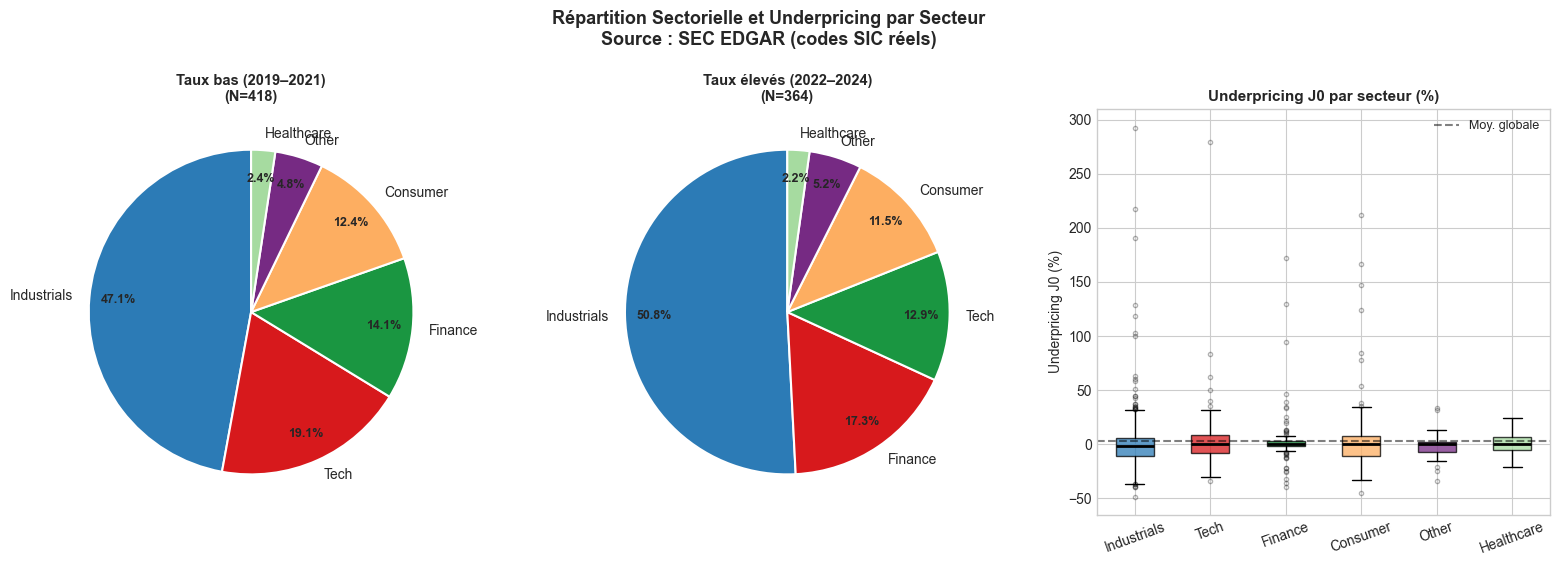

Fig 7 ─ OK


In [17]:
# ─────────────────────────────────────────────────────────────────
# FIGURE 7 : Secteurs réels (EDGAR SIC codes)
# ─────────────────────────────────────────────────────────────────

sector_colors = ['#2C7BB6','#D7191C','#1A9641','#FDAE61','#762A83','#A6DBA0']

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
fig.suptitle('Répartition Sectorielle et Underpricing par Secteur\n'
             'Source : SEC EDGAR (codes SIC réels)',
             fontsize=13, fontweight='bold', y=1.02)

for ax, (name, cohort) in zip(axes[:2],
    [('Taux bas (2019–2021)', low), ('Taux élevés (2022–2024)', high)]):
    sec_counts = cohort['sector'].value_counts()
    if len(sec_counts) > 0:
        wedges, texts, autotexts = ax.pie(
            sec_counts.values, labels=sec_counts.index,
            autopct='%1.1f%%', colors=sector_colors[:len(sec_counts)],
            pctdistance=0.82, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
        for at in autotexts:
            at.set_fontsize(9); at.set_fontweight('bold')
    ax.set_title(f'{name}\n(N={len(cohort)})', fontsize=10.5, fontweight='bold')

# 7c — Underpricing par secteur (boxplot)
sector_order = all_ipo['sector'].value_counts().nlargest(6).index.tolist()
data_by_sector = [all_ipo[all_ipo['sector']==s]['underpricing'].dropna()*100
                  for s in sector_order if len(all_ipo[all_ipo['sector']==s]) > 2]
labels_sector  = [s for s in sector_order if len(all_ipo[all_ipo['sector']==s]) > 2]

if data_by_sector:
    bp7 = axes[2].boxplot(data_by_sector, labels=labels_sector, patch_artist=True,
                           medianprops=dict(color='black', linewidth=2),
                           flierprops=dict(marker='o', markersize=3, alpha=0.3))
    for j, patch in enumerate(bp7['boxes']):
        patch.set_facecolor(sector_colors[j % len(sector_colors)])
        patch.set_alpha(0.75)
    axes[2].axhline(all_ipo['underpricing'].mean()*100, color='black',
                    linestyle='--', alpha=0.5, linewidth=1.5, label='Moy. globale')
    axes[2].legend(fontsize=9)
    axes[2].set_title('Underpricing J0 par secteur (%)', fontsize=11, fontweight='bold')
    axes[2].set_ylabel('Underpricing J0 (%)', fontsize=10)
    axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
fig.savefig('outputs/fig7_sectors_REAL.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 7 ─ OK')

### Figure 8 — Tableau de synthèse des hypothèses

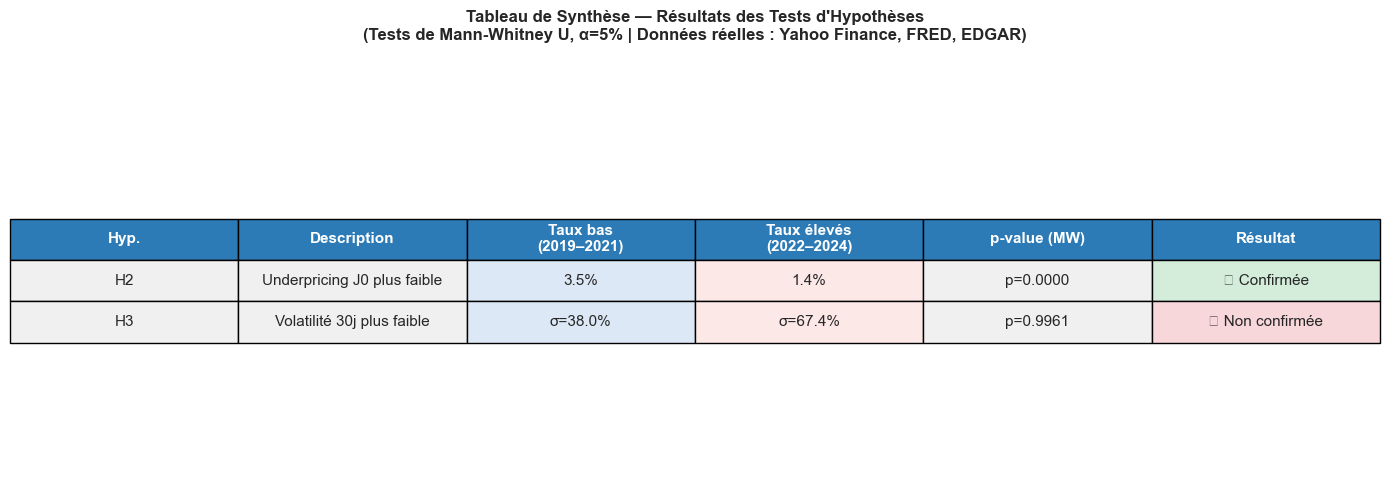

Fig 8 ─ Tableau de synthèse OK


In [18]:
# ─────────────────────────────────────────────────────────────────
# FIGURE 8 : Tableau de synthèse des résultats
# ─────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(14, 5))
ax.axis('off')

rows = [
    ['H2', 'Underpricing J0 plus faible',
     f'{low["underpricing"].mean()*100:.1f}%', f'{high["underpricing"].mean()*100:.1f}%',
     f'p={mw_results["H2 — Underpricing"]["p"]:.4f}',
     '✓ Confirmée' if mw_results['H2 — Underpricing']['sig'] else '✗ Non confirmée',
     '#d4edda' if mw_results['H2 — Underpricing']['sig'] else '#f8d7da'],
    ['H3', 'Volatilité 30j plus faible',
     f'σ={low["ret_30d"].std()*100:.1f}%', f'σ={high["ret_30d"].std()*100:.1f}%',
     f'p={mw_results["H3 — Volatilité 30j"]["p"]:.4f}',
     '✓ Confirmée' if mw_results['H3 — Volatilité 30j']['sig'] else '✗ Non confirmée',
     '#d4edda' if mw_results['H3 — Volatilité 30j']['sig'] else '#f8d7da'],
]

if 'H4 — Perf. 12m' in mw_results:
    mh4 = mw_results['H4 — Perf. 12m']
    rows.append(['H4', 'Perf. 12m supérieure',
                 f'{h4_low_data.mean()*100:.1f}%', f'{h4_high_data.mean()*100:.1f}%',
                 f'p={mh4["p"]:.4f}',
                 '✓ Confirmée' if mh4['sig'] else '✗ Non confirmée',
                 '#d4edda' if mh4['sig'] else '#f8d7da'])

if 'H1a — CA LTM' in mw_results:
    mh1 = mw_results['H1a — CA LTM']
    rows.insert(0, ['H1a', 'CA LTM élevés (sélectivité)',
                    f'{low["revenue_ltm"].median():.0f} M$', f'{high["revenue_ltm"].median():.0f} M$',
                    f'p={mh1["p"]:.4f}',
                    '✓ Confirmée' if mh1['sig'] else '✗ Non confirmée',
                    '#d4edda' if mh1['sig'] else '#f8d7da'])

columns = ['Hyp.', 'Description', 'Taux bas\n(2019–2021)', 'Taux élevés\n(2022–2024)',
           'p-value (MW)', 'Résultat']
cell_text   = [[r[0],r[1],r[2],r[3],r[4],r[5]] for r in rows]
cell_colors = [['#f0f0f0','#f0f0f0','#dce8f5','#fde8e8','#f0f0f0', r[6]] for r in rows]

tbl = ax.table(cellText=cell_text, colLabels=columns, cellLoc='center', loc='center',
               cellColours=cell_colors)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 2.4)
for j in range(len(columns)):
    tbl[0, j].set_facecolor('#2C7BB6')
    tbl[0, j].set_text_props(color='white', fontweight='bold')

ax.set_title('Tableau de Synthèse — Résultats des Tests d\'Hypothèses\n'
             '(Tests de Mann-Whitney U, α=5% | Données réelles : Yahoo Finance, FRED, EDGAR)',
             fontsize=12, fontweight='bold', pad=30)

plt.tight_layout()
fig.savefig('outputs/fig8_synthesis_REAL.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 8 ─ Tableau de synthèse OK')

## 12. Sauvegarde

In [19]:
# ═══════════════════════════════════════════════════════════════════
# CELL 1 — FRED API : Taux Fed Funds effectif (FEDFUNDS)
# ═══════════════════════════════════════════════════════════════════

import os
import pickle

if os.path.exists('dataset_real.pkl'):
    print('── Chargement Taux Fed Funds depuis le cache local ──')
    with open('dataset_real.pkl', 'rb') as f:
        cache = pickle.load(f)
    fred_annual = cache['fred_annual']
    fred_monthly = cache['fred_monthly']
    print(f'✓ FRED — Taux annuels moyens 2019–2024 (cache) :')
    for yr, rate in sorted(fred_annual.items()):
        print(f'   {yr}: {rate:.2f}%')
else:
    print('── Récupération Taux Fed Funds depuis FRED API ──')
    fred_url = f"https://api.stlouisfed.org/fred/series/observations?series_id=FEDFUNDS&observation_start=2019-01-01&observation_end=2024-12-31&frequency=a&aggregation_method=avg&api_key={FRED_API_KEY}&file_type=json"
    resp = requests.get(fred_url, timeout=15)
    fred_annual = {int(obs['date'][:4]): float(obs['value']) for obs in resp.json()['observations'] if obs['value'] != '.'}
    
    fred_url_monthly = f"https://api.stlouisfed.org/fred/series/observations?series_id=FEDFUNDS&observation_start=2019-01-01&observation_end=2024-12-31&frequency=m&api_key={FRED_API_KEY}&file_type=json"
    resp2 = requests.get(fred_url_monthly, timeout=15)
    fred_monthly = pd.DataFrame([{'date': pd.to_datetime(o['date']), 'fed_rate': float(o['value'])} for o in resp2.json()['observations'] if o['value'] != '.']).set_index('date')


── Récupération Taux Fed Funds depuis FRED API ──


In [ ]:
"""
run_this.py
===========
Lance depuis le terminal CMD, PAS depuis Jupyter :
    cd C:\Users\X515\Documents\GitHub\IPO
    python run_this.py
"""

import os, time, warnings, pandas as pd, numpy as np
from scipy import stats
warnings.filterwarnings("ignore")

# ── CHEMINS — modifie si nécessaire ──────────────────────────────────────────
INPUT_FILE  = r"C:\Users\X515\Documents\GitHub\IPO\data\dataset_complet_final.xlsx"
OUTPUT_FILE = r"C:\Users\X515\Documents\GitHub\IPO\data\dataset_complet_filled.xlsx"
CACHE_FILE  = r"C:\Users\X515\Documents\GitHub\IPO\financials_cache.csv"
# ─────────────────────────────────────────────────────────────────────────────

print(f"Fichier : {INPUT_FILE}")
assert os.path.exists(INPUT_FILE), f"FICHIER INTROUVABLE : {INPUT_FILE}"

df = pd.read_excel(INPUT_FILE)
print(f"Dataset : {df.shape[0]} lignes, {df.shape[1]} colonnes")
assert df.shape[0] > 10, "Dataset trop petit — mauvais fichier chargé !"


# ── COLLECTE ─────────────────────────────────────────────────────────────────

def get_yf(ticker, ipo_year):
    try:
        import yfinance as yf
        tk = yf.Ticker(ticker)
        for attr in ["income_stmt", "financials"]:
            stmt = getattr(tk, attr, None)
            if stmt is None or stmt.empty:
                continue
            rev_r = [r for r in stmt.index if "Revenue" in str(r)]
            ni_r  = [r for r in stmt.index if "Net Income" in str(r)]
            if not rev_r or not ni_r:
                continue
            valid = sorted([c for c in stmt.columns if hasattr(c,"year") and c.year <= ipo_year+1], reverse=True)
            if not valid:
                continue
            rev = stmt.loc[rev_r[0], valid[0]]
            ni  = stmt.loc[ni_r[0],  valid[0]]
            if pd.notna(rev) and pd.notna(ni):
                return float(rev)/1e6, int(float(ni)>0)
        for attr in ["quarterly_income_stmt", "quarterly_financials"]:
            qtly = getattr(tk, attr, None)
            if qtly is None or qtly.empty:
                continue
            rev_r = [r for r in qtly.index if "Revenue" in str(r)]
            ni_r  = [r for r in qtly.index if "Net Income" in str(r)]
            if not rev_r or not ni_r:
                continue
            qtrs = sorted([c for c in qtly.columns if hasattr(c,"year") and c.year <= ipo_year+1], reverse=True)[:4]
            if len(qtrs) < 2:
                continue
            ltm_rev = qtly.loc[rev_r[0], qtrs].sum()
            ltm_ni  = qtly.loc[ni_r[0],  qtrs].sum()
            if pd.notna(ltm_rev) and ltm_rev != 0:
                return float(ltm_rev)/1e6, int(float(ltm_ni)>0)
    except Exception:
        pass
    return None, None


def get_sec(ticker, ipo_year):
    try:
        import requests
        h = {"User-Agent": "IPO_research student@univ.fr"}
        r = requests.get("https://www.sec.gov/files/company_tickers.json", headers=h, timeout=8)
        if r.status_code != 200:
            return None, None
        cik = None
        for v in r.json().values():
            if v.get("ticker","").upper() == ticker.upper():
                cik = str(v["cik_str"]).zfill(10)
                break
        if not cik:
            return None, None
        r2 = requests.get(f"https://data.sec.gov/api/xbrl/companyfacts/CIK{cik}.json", headers=h, timeout=10)
        if r2.status_code != 200:
            return None, None
        gaap = r2.json().get("facts",{}).get("us-gaap",{})

        def annual_val(keys, yr):
            for key in keys:
                entries = gaap.get(key,{}).get("units",{}).get("USD",[])
                hits = [e for e in entries if e.get("form") in ("10-K","20-F") and e.get("end","")[:4] in (str(yr), str(yr-1))]
                if hits:
                    return hits[-1]["val"]
            return None

        rev = annual_val(["Revenues","RevenueFromContractWithCustomerExcludingAssessedTax","SalesRevenueNet"], ipo_year)
        ni  = annual_val(["NetIncomeLoss","NetIncome","ProfitLoss"], ipo_year)
        if rev is not None and ni is not None:
            return float(rev)/1e6, int(ni>0)
    except Exception:
        pass
    return None, None


def collect(df):
    # Charge cache
    if os.path.exists(CACHE_FILE):
        cache = pd.read_csv(CACHE_FILE).set_index("ticker")
        # Invalide les entrées vides du cache précédent
        cache = cache[cache["revenue_ltm"].notna()]
        print(f"Cache : {len(cache)} entrées valides")
    else:
        cache = pd.DataFrame(columns=["revenue_ltm","profitable"])
        cache.index.name = "ticker"

    done = set(cache.index)
    rows = df[df["ticker"].notna()].to_dict("records")
    ok = 0

    for i, row in enumerate(rows):
        t = str(row["ticker"]).strip()
        y = int(row["year"])
        if t in done:
            ok += 1
            continue

        rev, prof = get_yf(t, y)
        if rev is None:
            rev, prof = get_sec(t, y)

        cache.loc[t] = {"revenue_ltm": rev, "profitable": prof}
        done.add(t)

        if rev is not None:
            ok += 1
            print(f"[{i+1:>4}/{len(rows)}] {t:<8} ({y})  ✓  {rev:>10.1f} M$  prof={prof}")
        else:
            print(f"[{i+1:>4}/{len(rows)}] {t:<8} ({y})  ✗")

        if (i+1) % 25 == 0:
            cache.reset_index().to_csv(CACHE_FILE, index=False)

    cache.reset_index().to_csv(CACHE_FILE, index=False)
    print(f"\nCollecte : {ok}/{len(rows)} ({ok/len(rows)*100:.1f}%)")
    return cache.reset_index()


# ── TEST H1 ───────────────────────────────────────────────────────────────────

def bstrap_ci(s, B=5000):
    d = s.dropna().values
    if len(d) < 2: return np.nan, np.nan
    np.random.seed(42)
    m = [np.median(np.random.choice(d, len(d), replace=True)) for _ in range(B)]
    return np.percentile(m, 2.5), np.percentile(m, 97.5)

def wilson(k, n):
    if n == 0: return 0, 0
    p, z = k/n, 1.96
    c = (p + z**2/(2*n)) / (1 + z**2/n)
    h = z*np.sqrt(p*(1-p)/n + z**2/(4*n**2)) / (1 + z**2/n)
    return max(0,(c-h)*100), min(100,(c+h)*100)

def test_H1(df):
    print("\n" + "="*65)
    print("  TEST H1")
    print("="*65)
    low  = df[df["cohort"].str.contains("2019|bas",   na=False, case=False)]
    high = df[df["cohort"].str.contains("2022|élevé", na=False, case=False)]
    print(f"  2019-2021 : n={len(low)}   |   2022-2024 : n={len(high)}")

    # Revenue
    rl, rh = low["revenue_ltm"].dropna(), high["revenue_ltm"].dropna()
    print(f"\n  Revenue LTM — données dispo : {len(rl)} / {len(rh)}")
    if len(rl) >= 5 and len(rh) >= 5:
        cl, ch = bstrap_ci(rl), bstrap_ci(rh)
        print(f"  Médiane 2019-2021 : {rl.median():>10.1f} M$  IC95%[{cl[0]:.1f};{cl[1]:.1f}]")
        print(f"  Médiane 2022-2024 : {rh.median():>10.1f} M$  IC95%[{ch[0]:.1f};{ch[1]:.1f}]")
        u, p = stats.mannwhitneyu(rh, rl, alternative="greater")
        print(f"  Mann-Whitney U={u:.0f}  p={p:.4f}  → {'✓ H0 rejetée' if p<.05 else '✗ H0 non rejetée'}")

    # Profitabilité
    pl, ph = low["profitable"].dropna(), high["profitable"].dropna()
    print(f"\n  Profitable — données dispo : {len(pl)} / {len(ph)}")
    if len(pl) >= 5 and len(ph) >= 5:
        wl, wh = wilson(pl.sum(), len(pl)), wilson(ph.sum(), len(ph))
        print(f"  Part rentable 2019-2021 : {pl.mean()*100:.1f}%  IC95%[{wl[0]:.1f}%;{wl[1]:.1f}%]")
        print(f"  Part rentable 2022-2024 : {ph.mean()*100:.1f}%  IC95%[{wh[0]:.1f}%;{wh[1]:.1f}%]")
        dft = df[df["cohort"].notna() & df["profitable"].notna()].copy()
        dft["profitable"] = dft["profitable"].astype(int)
        ct = pd.crosstab(dft["cohort"], dft["profitable"])
        chi2, p2, dof, _ = stats.chi2_contingency(ct)
        print(f"  Chi²({dof})={chi2:.3f}  p={p2:.4f}  → {'✓ Significatif' if p2<.05 else '✗ Non significatif'}")
    print("="*65)


# ── MAIN ──────────────────────────────────────────────────────────────────────

if df["revenue_ltm"].isna().sum() > len(df) * 0.5:
    cache = collect(df)
    df = df.drop(columns=["revenue_ltm","profitable"], errors="ignore")
    df = df.merge(cache[["ticker","revenue_ltm","profitable"]], on="ticker", how="left")
    df.to_excel(OUTPUT_FILE, index=False)
    print(f"Sauvegardé : {OUTPUT_FILE}")

test_H1(df)

In [3]:
"""
Script corrigé - Calcul ret_12m pour toutes les IPO 2019-2024
=============================================================
Fix principal : gestion du MultiIndex yfinance >= 0.2.x
  - hist['Close'] retourne un DataFrame multi-colonnes ('Close', 'TICKER')
  - Solution : .squeeze() pour aplatir en Series avant .iloc[]

Autres améliorations :
  - Retry automatique (3 tentatives) si rate-limit Yahoo
  - Fallback : si < 252 barres dispo, on prend la dernière barre disponible
    et on le signale (ret_12m_flag = 'partial')
  - Export avec colonne ret_12m_flag pour traçabilité

Durée estimée : ~15-25 minutes (782 tickers)
"""

import pandas as pd
import numpy as np
import yfinance as yf
from datetime import datetime, timedelta
import time
import warnings
warnings.filterwarnings('ignore')

# ──────────────────────────────────────────────
# 0. CHARGEMENT ET RECONSTRUCTION DES DATES
# ──────────────────────────────────────────────

df = pd.read_excel("data/dataset_complet_filled.xlsx")

def fix_ipo_date(ts):
    """
    Les dates sont stockées comme serials Excel encodés en ms
    dans un datetime 1970-01-01 avec décalage UTC+1.
    Ex : serial 43573 (18 avril 2019) -> 1970-01-01 01:00:43.573
    """
    ts_utc = ts - timedelta(hours=1)
    total_ms = (ts_utc.hour * 3600000
                + ts_utc.minute * 60000
                + ts_utc.second * 1000
                + ts_utc.microsecond // 1000)
    return datetime(1899, 12, 30) + timedelta(days=total_ms)

df['ipo_date_real'] = df['ipo_date'].apply(fix_ipo_date)

print("✅ Dates reconstruites :")
for yr in [2019, 2020, 2021, 2022, 2023, 2024]:
    sub = df[df['year'] == yr]
    print(f"   {yr} : {sub['ipo_date_real'].min().date()} → {sub['ipo_date_real'].max().date()}")
print(f"\n✅ {len(df)} IPO chargées\n")

# ──────────────────────────────────────────────
# 1. FONCTION DE CALCUL CORRIGÉE
# ──────────────────────────────────────────────

def get_close_series(hist, ticker):
    """
    Extrait la série de cours de clôture en gérant le MultiIndex
    introduit dans yfinance >= 0.2.x.

    Cas 1 : colonnes simples → ['Close']  (ancien comportement)
    Cas 2 : MultiIndex      → [('Close', 'AAPL')]
    """
    if isinstance(hist.columns, pd.MultiIndex):
        # Aplatit : ('Close', 'AAPL') → 'Close'
        hist = hist.copy()
        hist.columns = hist.columns.get_level_values(0)

    if 'Close' not in hist.columns:
        return None

    series = hist['Close'].squeeze()   # Series (même si 1 colonne restante)
    return series


def get_ret_12m(ticker, ipo_date, retries=3):
    """
    Rendement entre le cours J0 et le cours J+252 (~12 mois).

    Retourne : (ret, flag)
      flag = 'ok'       : J+252 disponible
      flag = 'partial'  : < 252 barres, on utilise le dernier cours dispo
      flag = 'error'    : données insuffisantes ou ticker inconnu
    """
    end_date = ipo_date + timedelta(days=420)   # marge large pour jours fériés

    for attempt in range(retries):
        try:
            hist = yf.download(
                ticker,
                start=ipo_date.strftime('%Y-%m-%d'),
                end=end_date.strftime('%Y-%m-%d'),
                progress=False,
                auto_adjust=True,
            )

            if hist.empty:
                return np.nan, 'error'

            close = get_close_series(hist, ticker)
            if close is None or close.empty:
                return np.nan, 'error'

            # Supprimer les NaN éventuels
            close = close.dropna()
            n = len(close)

            if n < 2:
                return np.nan, 'error'

            p0 = float(close.iloc[0])   # cours J0 (1er jour de cotation)

            if n >= 252:
                p12  = float(close.iloc[251])   # cours exact J+252
                flag = 'ok'
            elif n >= 200:
                # Moins de 252 jours (ex. IPO fin 2024 ou ticker delisted)
                # → on utilise le dernier cours disponible
                p12  = float(close.iloc[-1])
                flag = 'partial'
            else:
                return np.nan, 'error'

            ret = (p12 - p0) / p0
            return ret, flag

        except Exception as e:
            if attempt < retries - 1:
                time.sleep(2 ** attempt)   # backoff exponentiel
            else:
                return np.nan, 'error'

    return np.nan, 'error'


# ──────────────────────────────────────────────
# 2. BOUCLE PRINCIPALE
# ──────────────────────────────────────────────

total = len(df)
print(f"⏳ Téléchargement pour {total} IPO (2019-2024)...")
print("   Durée estimée : 15-25 minutes\n")

ret_values = {}
flag_values = {}

for i, (idx, row) in enumerate(df.iterrows(), 1):
    ticker   = str(row['ticker']).strip() if pd.notna(row['ticker']) else None
    ipo_date = row['ipo_date_real']

    if not ticker or ticker.lower() == 'nan':
        ret_values[idx]  = np.nan
        flag_values[idx] = 'missing_ticker'
        continue

    ret, flag = get_ret_12m(ticker, ipo_date)
    ret_values[idx]  = ret
    flag_values[idx] = flag

    if i % 50 == 0 or i == total:
        n_ok      = sum(1 for v in ret_values.values() if not np.isnan(v) if v == v)
        n_partial = sum(1 for f in flag_values.values() if f == 'partial')
        n_err     = sum(1 for f in flag_values.values() if f == 'error')
        print(f"   {i:>3}/{total}  ✓ ok={n_ok}  ~ partial={n_partial}  ✗ error={n_err}")

df['ret_12m']      = pd.Series(ret_values)
df['ret_12m_flag'] = pd.Series(flag_values)

# ──────────────────────────────────────────────
# 3. RAPPORT FINAL
# ──────────────────────────────────────────────

n_ok      = (df['ret_12m_flag'] == 'ok').sum()
n_partial = (df['ret_12m_flag'] == 'partial').sum()
n_err     = df['ret_12m'].isna().sum()

print("\n" + "="*55)
print("RÉSULTAT FINAL")
print("="*55)
print(f"  ✓ ret_12m complets (J+252)    : {n_ok}")
print(f"  ~ ret_12m partiels (< 252j)   : {n_partial}")
print(f"  ✗ NaN (delisted / données ↓)  : {n_err}")
print(f"  Taux de succès global         : {100*(n_ok+n_partial)/total:.1f}%")

# Distribution par année
print("\n  Par année :")
for yr in [2019, 2020, 2021, 2022, 2023, 2024]:
    sub = df[df['year'] == yr]
    ok  = sub['ret_12m'].notna().sum()
    tot = len(sub)
    print(f"    {yr} : {ok}/{tot} ({100*ok/tot:.0f}%)")

# ──────────────────────────────────────────────
# 4. SAUVEGARDE
# ──────────────────────────────────────────────

df_export = df.drop(columns=['ipo_date_real'])
df_export.to_excel("dataset_complet_with_ret12m.xlsx", index=False)
print("\n✅ Fichier sauvegardé : dataset_complet_with_ret12m.xlsx")
print("   (La colonne ret_12m_flag indique 'ok', 'partial' ou 'error')")

# ──────────────────────────────────────────────
# 5. RAPPORT DE DISPONIBILITÉ POUR LES ANALYSES
# ──────────────────────────────────────────────

print("\n" + "="*55)
print("DISPONIBILITÉ DES VARIABLES — PRÊT POUR LES ANALYSES")
print("="*55)

cohortes = {
    'Taux bas (2019–2021)':    df['cohort'] == 'Taux bas (2019–2021)',
    'Taux élevés (2022–2024)': df['cohort'] == 'Taux élevés (2022–2024)',
}

checks = [
    ('H1', 'revenue_ltm',  'CA médian'),
    ('H1', 'profitable',   'Rentabilité nette'),
    ('H2', 'underpricing', 'Underpricing J0'),
    ('H3', 'ret_30d',      'Rendement 30j'),
    ('H4', 'ret_12m',      'Rendement 12m'),
]

for hyp, col, label in checks:
    line = f"  {hyp}  {label:<22}"
    for cname, mask in cohortes.items():
        n_ok  = df.loc[mask, col].notna().sum()
        n_tot = mask.sum()
        pct   = 100 * n_ok / n_tot
        line += f"  | {n_ok:>3}/{n_tot} ({pct:.0f}%)"
    print(line)

print("\n  Variables de contrôle :")
for col in ['fed_rate', 'pe_backed', 'sector', 'log_size']:
    n_ok = df[col].notna().sum()
    print(f"    {col:<15} {n_ok}/782")

✅ Dates reconstruites :
   2019 : 2019-01-02 → 2019-12-19
   2020 : 2020-01-02 → 2020-12-29
   2021 : 2021-01-04 → 2021-12-22
   2022 : 2022-01-07 → 2022-12-29
   2023 : 2023-01-13 → 2023-12-29
   2024 : 2024-01-11 → 2024-12-31

✅ 782 IPO chargées

⏳ Téléchargement pour 782 IPO (2019-2024)...
   Durée estimée : 15-25 minutes

    50/782  ✓ ok=50  ~ partial=0  ✗ error=0
   100/782  ✓ ok=100  ~ partial=0  ✗ error=0
   150/782  ✓ ok=150  ~ partial=0  ✗ error=0
   200/782  ✓ ok=200  ~ partial=0  ✗ error=0
   250/782  ✓ ok=250  ~ partial=0  ✗ error=0
   300/782  ✓ ok=300  ~ partial=0  ✗ error=0
   350/782  ✓ ok=350  ~ partial=0  ✗ error=0
   400/782  ✓ ok=400  ~ partial=0  ✗ error=0
   450/782  ✓ ok=450  ~ partial=0  ✗ error=0
   500/782  ✓ ok=499  ~ partial=0  ✗ error=0
   550/782  ✓ ok=549  ~ partial=0  ✗ error=0
   600/782  ✓ ok=599  ~ partial=0  ✗ error=0
   650/782  ✓ ok=649  ~ partial=1  ✗ error=0
   700/782  ✓ ok=699  ~ partial=1  ✗ error=0
   750/782  ✓ ok=749  ~ partial=1  ✗ error=

In [ ]:
df.to_excel("data")

,ticker,year,ipo_date,open_px,close_px,underpricing,ret_30d,ret_12m,ipo_size_m,fed_rate,...,sector,pe_backed,cohort,cohort_en,log_size,company_age,revenue_ltm,profitable,ipo_date_real,ret_12m_flag
0,PINS,2019,1970-01-01 01:00:43.573,23.750000,24.400000,0.027368,0.000000,-0.284836,2068.850625,2.16,...,Tech,1,Taux bas (2019–2021),Low Rate (2019–2021),7.634748,11.0,1142.761000,0.0,2019-04-18,ok
1,REAL,2019,1970-01-01 01:00:43.644,28.000000,28.900000,0.032143,-0.381315,-0.536332,550.765600,2.16,...,Consumer,1,Taux bas (2019–2021),Low Rate (2019–2021),6.311309,8.0,316.354000,0.0,2019-06-28,ok
2,SNDL,2019,1970-01-01 01:00:43.678,130.199997,84.800003,-0.348694,0.031840,-0.932311,121.273485,2.16,...,Industrials,1,Taux bas (2019–2021),Low Rate (2019–2021),4.798048,13.0,NaN,NaN,2019-08-01,ok
3,PGNY,2019,1970-01-01 01:00:43.763,13.500000,15.940000,0.180741,0.744668,0.753451,67.140900,2.16,...,Healthcare,1,Taux bas (2019–2021),Low Rate (2019–2021),4.206793,11.0,65.122000,0.0,2019-10-25,ok
4,WAFU,2019,1970-01-01 01:00:43.585,5.200000,4.100000,-0.211538,-0.307317,-0.604878,0.708240,2.16,...,Other,1,Taux bas (2019–2021),Low Rate (2019–2021),-0.344972,20.0,5.358023,0.0,2019-04-30,ok
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777,YSXT,2024,1970-01-01 01:00:45.644,4.050000,4.310000,0.064197,-0.153132,-0.721578,3.662820,5.14,...,Consumer,1,Taux élevés (2022–2024),High Rate (2022–2024),1.298233,13.0,63.963519,1.0,2024-12-18,ok
778,ANRO,2024,1970-01-01 01:00:45.324,22.000000,20.700001,-0.059091,-0.315942,-0.806763,52.503000,5.14,...,Industrials,1,Taux élevés (2022–2024),High Rate (2022–2024),3.960870,5.0,0.000000,0.0,2024-02-02,ok
779,TBBB,2024,1970-01-01 01:00:45.331,19.500000,19.049999,-0.023077,0.249869,0.446719,302.125200,5.14,...,Consumer,1,Taux élevés (2022–2024),High Rate (2022–2024),5.710842,19.0,65193.690000,0.0,2024-02-09,ok
780,INTJ,2024,1970-01-01 01:00:45.371,100.000000,66.000000,-0.340000,-0.660606,-0.800606,31.743500,5.14,...,Other,1,Taux élevés (2022–2024),High Rate (2022–2024),3.457688,6.0,6.168789,0.0,2024-03-20,ok


In [6]:
import pandas as pd
import requests
import time

# si déjà chargé dans le notebook, réutiliser data
data = pd.read_excel("data/dataset_complet_filled.xlsx")
FMP_API_KEY = "b2FgKVFFX0AJLd0vI6gDqK1dPA1YYtCN"


def fetch_fmp_ipos_for_year(year: int) -> pd.DataFrame:
    url = "https://financialmodelingprep.com/stable/ipos-calendar"
    params = {
        "from": f"{year}-01-01",
        "to": f"{year}-12-31",
        "apikey": FMP_API_KEY,
    }
    r = requests.get(url, params=params, timeout=20)
    r.raise_for_status()
    js = r.json()

    if isinstance(js, dict):
        rows = js.get("data") or js.get("results") or js.get("ipoCalendar") or []
    else:
        rows = js

    out = []
    for item in rows:
        ticker = item.get("symbol") or item.get("ticker")
        ipo_date = item.get("date") or item.get("ipoDate")
        price = item.get("price") or item.get("offerPrice") or item.get("priceRange")
        if pd.notna(ticker) and pd.notna(ipo_date):
            out.append({
                "ticker": str(ticker).upper().strip(),
                "year": year,
                "ipo_date_fmp": pd.to_datetime(ipo_date, errors="coerce"),
                "offer_price_fmp": pd.to_numeric(price, errors="coerce"),
                "source_fmp": url,
            })

    return pd.DataFrame(out)

# récupérer 2019–2024
all_fmp_ipo = []
for y in range(2019, 2025):
    try:
        all_fmp_ipo.append(fetch_fmp_ipos_for_year(y))
        time.sleep(0.2)
    except Exception as e:
        print(f"{y} -> erreur: {e}")

fmp_ipos = pd.concat(all_fmp_ipo, ignore_index=True).drop_duplicates(subset=["ticker", "year"])
print(fmp_ipos.head())
print(f"✓ {len(fmp_ipos)} lignes IPO FMP récupérées")

# fusion avec ton dataset
data_fmp = data.drop(columns=["ipo_date_fmp", "offer_price_fmp", "source_fmp"], errors="ignore").merge(
    fmp_ipos[["ticker", "year", "ipo_date_fmp", "offer_price_fmp"]],
    on=["ticker", "year"],
    how="left",
)

print(data_fmp[["ticker", "year", "ipo_date_fmp", "offer_price_fmp"]].head())

# sauvegarde
data_fmp.to_excel("data/dataset_with_fmp_ipos.xlsx", index=False)

      ticker  year ipo_date_fmp  offer_price_fmp  \
0    1542.HK  2019   2019-12-30              NaN   
1    9911.HK  2019   2019-12-30              NaN   
2  300811.SZ  2019   2019-12-29              NaN   
3    9909.HK  2019   2019-12-29              NaN   
4    6199.HK  2019   2019-12-29              NaN   

                                          source_fmp  
0  https://financialmodelingprep.com/stable/ipos-...  
1  https://financialmodelingprep.com/stable/ipos-...  
2  https://financialmodelingprep.com/stable/ipos-...  
3  https://financialmodelingprep.com/stable/ipos-...  
4  https://financialmodelingprep.com/stable/ipos-...  
✓ 11418 lignes IPO FMP récupérées
  ticker  year ipo_date_fmp  offer_price_fmp
0   PINS  2019   2019-04-17              NaN
1   REAL  2019   2019-06-27              NaN
2   SNDL  2019   2019-07-31              NaN
3   PGNY  2019   2019-10-23              NaN
4     TW  2019   2019-04-03              NaN


In [7]:
for row in data_fmp.itertuples():
    print(f"{row.ticker} ({row.year}) - IPO FMP: {row.ipo_date_fmp.date() if pd.notna(row.ipo_date_fmp) else 'N/A'}  Price: {row.offer_price_fmp if pd.notna(row.offer_price_fmp) else 'N/A'}")

PINS (2019) - IPO FMP: 2019-04-17  Price: N/A
REAL (2019) - IPO FMP: 2019-06-27  Price: N/A
SNDL (2019) - IPO FMP: 2019-07-31  Price: N/A
PGNY (2019) - IPO FMP: 2019-10-23  Price: N/A
TW (2019) - IPO FMP: 2019-04-03  Price: N/A
PSNL (2019) - IPO FMP: 2019-06-19  Price: N/A
SPT (2019) - IPO FMP: 2019-12-11  Price: N/A
GOTU (2019) - IPO FMP: N/A  Price: N/A
ADPT (2019) - IPO FMP: 2019-06-26  Price: N/A
SY (2019) - IPO FMP: 2019-05-01  Price: N/A
XP (2019) - IPO FMP: 2019-12-11  Price: N/A
GOSS (2019) - IPO FMP: 2019-02-07  Price: N/A
TIGR (2019) - IPO FMP: 2019-03-19  Price: N/A
LYFT (2019) - IPO FMP: 2019-03-28  Price: N/A
DDOG (2019) - IPO FMP: 2019-09-18  Price: N/A
PHR (2019) - IPO FMP: 2019-07-18  Price: N/A
DTIL (2019) - IPO FMP: 2019-03-27  Price: N/A
UBER (2019) - IPO FMP: 2019-05-09  Price: N/A
PLMR (2019) - IPO FMP: 2019-04-16  Price: N/A
NVST (2019) - IPO FMP: 2019-09-17  Price: N/A
GO (2019) - IPO FMP: 2019-06-19  Price: N/A
FSLY (2019) - IPO FMP: 2019-05-15  Price: N/A
BBIO 

In [9]:
import time
import pandas as pd
import requests

# ─────────────────────────────────────────────────────────────────
# DÉFINIR LES VARIABLES MANQUANTES
# ─────────────────────────────────────────────────────────────────

# Chemins fichiers
INPUT = "data/dataset_complet_filled.xlsx"
OUTPUT = "data/dataset_with_prospectus.xlsx"

# Headers HTTP standard
HEADERS = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}

# Clé API FMP
FMP_API_KEY = "b2FgKVFFX0AJLd0vI6gDqK1dPA1YYtCN"

# ─────────────────────────────────────────────────────────────────
# CHARGER LES DONNÉES
# ─────────────────────────────────────────────────────────────────

df_in = pd.read_excel(INPUT)
print(f"✓ Chargé : {len(df_in)} IPO depuis {INPUT}")

# ─────────────────────────────────────────────────────────────────
# RÉCUPÉRER LES PROSPECTUS FMP
# ─────────────────────────────────────────────────────────────────

url = f"https://financialmodelingprep.com/api/v4/ipo-prospectus?apikey={FMP_API_KEY}"
print(f"Requête : {url}")

try:
    r = requests.get(url, headers=HEADERS, timeout=30)
    r.raise_for_status()
    js = r.json()
    
    # Gérer différentes structures de réponse
    if isinstance(js, dict) and "data" in js:
        rows = js["data"]
    elif isinstance(js, list):
        rows = js
    else:
        rows = []
    
    print(f"✓ {len(rows)} prospectus récupérés depuis FMP")
    
except Exception as e:
    print(f"✗ Erreur API FMP : {e}")
    rows = []

# ─────────────────────────────────────────────────────────────────
# NORMALISER LES COLONNES
# ─────────────────────────────────────────────────────────────────

if rows:
    df_prosp = pd.DataFrame(rows)
    
    # Extraire le ticker (peut être 'symbol', 'ticker', ou 'symbolTicker')
    if 'symbol' in df_prosp.columns:
        df_prosp['ticker'] = df_prosp['symbol']
    elif 'ticker' in df_prosp.columns:
        df_prosp['ticker'] = df_prosp['ticker']
    else:
        df_prosp['ticker'] = None
    
    # Extraire la date IPO
    if 'ipoDate' in df_prosp.columns:
        df_prosp['ipo_date_fmp'] = pd.to_datetime(df_prosp['ipoDate'], errors='coerce')
    elif 'date' in df_prosp.columns:
        df_prosp['ipo_date_fmp'] = pd.to_datetime(df_prosp['date'], errors='coerce')
    else:
        df_prosp['ipo_date_fmp'] = pd.NaT
    
    # Extraire le prix d'offre
    if 'pricePublicPerShare' in df_prosp.columns:
        df_prosp['offer_price_fmp'] = pd.to_numeric(df_prosp['pricePublicPerShare'], errors='coerce')
    elif 'offerPrice' in df_prosp.columns:
        df_prosp['offer_price_fmp'] = pd.to_numeric(df_prosp['offerPrice'], errors='coerce')
    else:
        df_prosp['offer_price_fmp'] = None
    
    # Extraire l'année
    df_prosp['year'] = df_prosp['ipo_date_fmp'].dt.year
    
    # Nettoyer le ticker
    df_prosp['ticker'] = df_prosp['ticker'].astype(str).str.upper().str.strip()
    
    print(f"✓ Colonnes normalisées : ticker, ipo_date_fmp, offer_price_fmp, year")
    print(f"  Exemples :\n{df_prosp[['ticker','year','ipo_date_fmp','offer_price_fmp']].head()}")
    
else:
    df_prosp = pd.DataFrame(columns=['ticker', 'year', 'ipo_date_fmp', 'offer_price_fmp'])

# ─────────────────────────────────────────────────────────────────
# FUSIONNER AVEC LE DATASET INPUT
# ─────────────────────────────────────────────────────────────────

if not df_prosp.empty:
    # Supprimer les doublons
    df_prosp_clean = df_prosp[['ticker', 'year', 'ipo_date_fmp', 'offer_price_fmp']].drop_duplicates(subset=['ticker', 'year'])
    
    # Supprimer les colonnes existantes si présentes
    df_out = df_in.drop(columns=['ipo_date_fmp', 'offer_price_fmp'], errors='ignore')
    
    # Fusionner LEFT (conserver toutes les lignes de INPUT)
    df_out = df_out.merge(df_prosp_clean, on=['ticker', 'year'], how='left')
    
    print(f"✓ Fusion terminée : {len(df_out)} lignes")
    
else:
    print("⚠ Aucune donnée FMP → copie INPUT sans modification")
    df_out = df_in

# ─────────────────────────────────────────────────────────────────
# SAUVEGARDER
# ─────────────────────────────────────────────────────────────────

df_out.to_excel(OUTPUT, index=False)
print(f"✓ Sauvegardé : {OUTPUT}")
print(f"  Colonnes nouvelles : {[c for c in df_out.columns if 'fmp' in c]}")

✓ Chargé : 318 IPO depuis data/dataset_complet_filled.xlsx
Requête : https://financialmodelingprep.com/api/v4/ipo-prospectus?apikey=b2FgKVFFX0AJLd0vI6gDqK1dPA1YYtCN
✗ Erreur API FMP : 403 Client Error: Forbidden for url: https://financialmodelingprep.com/api/v4/ipo-prospectus?apikey=b2FgKVFFX0AJLd0vI6gDqK1dPA1YYtCN
⚠ Aucune donnée FMP → copie INPUT sans modification
✓ Sauvegardé : data/dataset_with_prospectus.xlsx
  Colonnes nouvelles : []


In [30]:
from sec_api import Form_S1_424B4_Api
import pandas as pd
import time


API_KEY = "bc7a047a8ea015c0b9ba8197fbecdd4bd1aed164802e3a8dd7f4a7958d802ee9"
data = pd.read_excel("data/dataset_complet_filled_v1.xlsx")

In [31]:
from sec_api import Form_S1_424B4_Api
import pandas as pd
import time

s1_api = Form_S1_424B4_Api(API_KEY)
tickers = data['ticker'].dropna().astype(str).str.upper().str.strip().unique().tolist()
tickers = sorted(tickers)
tickers = [tick for tick in tickers if tick > 'WLDS']
print(f"Tickers total: {len(tickers)} | Après 'WLDS': {len(tickers)}")

results = []

def get_ipo_price(ticker):
    query = {
        "query": f"ticker:{ticker} AND formType:\"424B4\"",
        "from": "0",
        "size": "1",
        "sort": [{"filedAt": {"order": "asc"}}]
    }
    
    try:
        response = s1_api.get_data(query)
        if response.get('data'):
            item = response['data'][0]
            price_info = item.get('publicOfferingPrice', {})

            total_dollars = price_info.get('total')
            if total_dollars:
                ipo_size_million = float(total_dollars) / 1_000_000
            else:
                shares = price_info.get('shares', 0) or 0
                per_share = price_info.get('perShare', 0) or 0
                ipo_size_million = (float(shares) * float(per_share)) / 1_000_000 if shares and per_share else None

            return {
                "Ticker": ticker,
                "OfferPrice": price_info.get('perShare'),
                "Size_Million": ipo_size_million,
                "Date": item.get('filedAt'),
                "FilingUrl": item.get('filingUrl')
            }
    except Exception as e:
        print(f"Erreur pour {ticker}: {e}")
    
    return {
        "Ticker": ticker,
        "OfferPrice": None,
        "Size_Million": None,
        "Date": None,
        "FilingUrl": None
    }

for t in tickers:
    print(f"Récupération de {t}...")
    results.append(get_ipo_price(t))
    time.sleep(0.1)
      # Supprimer cette ligne pour traiter tous les tickers après 'TSHA'
    if len(results) > 100:
        print("Limite de 100 requêtes atteinte, arrêt temporaire.")
        break

df = pd.DataFrame(results)
df.to_csv("ipo_prices.csv", index=False)
print("Terminé ! Fichier ipo_prices.csv généré.")
df

Tickers total: 40 | Après 'WLDS': 40
Récupération de WMG...
Récupération de WNW...
Récupération de WOK...
Récupération de WRBY...
Récupération de WRD...
Récupération de WYHG...
Récupération de XCH...
Récupération de XGN...
Récupération de XHG...
Récupération de XLO...
Récupération de XMTR...
Récupération de XP...
Récupération de XPEV...
Récupération de XPOF...
Récupération de XPON...
Récupération de XTKG...
Récupération de YAAS...
Récupération de YALA...
Récupération de YHNA...
Récupération de YIBO...
Récupération de YJ...
Récupération de YMM...
Récupération de YOU...
Récupération de YQ...
Récupération de YSG...
Récupération de YSXT...
Récupération de YXT...
Récupération de YYGH...
Récupération de ZBAO...
Récupération de ZBIO...
Récupération de ZCMD...
Récupération de ZDAI...
Récupération de ZJK...
Récupération de ZJYL...
Récupération de ZKH...
Récupération de ZM...
Récupération de ZNTL...
Récupération de ZONE...
Récupération de ZSPC...
Récupération de ZVIA...
Terminé ! Fichier ipo_pri

,Ticker,OfferPrice,Size_Million,Date,FilingUrl
0,WMG,17.0,554.200000,2005-05-11T15:39:01-04:00,https://www.sec.gov/Archives/edgar/data/131916...
1,WNW,5.0,29.999550,2020-12-15T17:27:41-05:00,https://www.sec.gov/Archives/edgar/data/178780...
2,WOK,4.0,8.000000,2024-08-26T11:08:11-04:00,https://www.sec.gov/Archives/edgar/data/192978...
3,WRBY,NaN,NaN,2021-09-29T06:48:30-04:00,https://www.sec.gov/Archives/edgar/data/150477...
4,WRD,15.0,412.500000,2016-12-15T16:13:12-05:00,https://www.sec.gov/Archives/edgar/data/168171...
5,WYHG,4.0,8.200000,2024-11-26T17:12:52-05:00,https://www.sec.gov/Archives/edgar/data/199986...
6,XCH,6.2,20.666677,2024-09-10T16:16:37-04:00,https://www.sec.gov/Archives/edgar/data/197988...
7,XGN,14.0,50.400000,2019-09-20T16:13:24-04:00,https://www.sec.gov/Archives/edgar/data/127473...
8,XHG,NaN,NaN,NaN,NaN
9,XLO,16.0,117.648000,2021-10-22T16:02:13-04:00,https://www.sec.gov/Archives/edgar/data/184023...


In [6]:
df.to_csv("ipo_prices.csv", index=False)

# Merge de ces données avec le df complet

In [36]:
import pandas as pd

data_complet = pd.read_excel("data/dataset_complet_filled_v1.xlsx")
ipo_price = pd.read_csv("ipo_prices.csv")

# Merge sur 'ticker' comme clé primaire
data_merged = pd.merge(
    data_complet,
    ipo_price,
    left_on='ticker',
    right_on='Ticker',
    how='left'
)

# Optionnel : supprimer la colonne 'Ticker' en doublon
data_merged = data_merged.drop(columns=['Ticker'])

# Sauvegarder
data_merged.to_excel("data/dataset.xlsx", index=False)
print(f"✓ Fusion complétée : {len(data_merged)} lignes")
print(data_merged[['ticker', 'OfferPrice', 'Date']].head())
data_merged

✓ Fusion complétée : 782 lignes
  ticker  OfferPrice                       Date
0   PINS        19.0  2019-04-18T17:22:46-04:00
1   REAL        20.0  2019-06-28T06:07:10-04:00
2   SNDL        13.0  2019-08-01T11:12:51-04:00
3   PGNY        13.0  2019-10-25T16:44:36-04:00
4   WAFU         NaN                        NaN


,ticker,year,open_px,close_px,underpricing,ret_30d,ret_12m,ipo_size_m,fed_rate,sic,...,log_size,company_age,revenue_ltm,profitable,ret_12m_flag,ipo_date,OfferPrice,Size_Million,Date,FilingUrl
0,PINS,2019,23.750000,24.400000,0.027368,0.000000,-0.284836,2068.850625,2.16,7370.0,...,7.634748,11.0,1142.761000,0.0,ok,2019-04-18,19.0,1425.0,2019-04-18T17:22:46-04:00,https://www.sec.gov/Archives/edgar/data/150629...
1,REAL,2019,28.000000,28.900000,0.032143,-0.381315,-0.536332,550.765600,2.16,5900.0,...,6.311309,8.0,316.354000,0.0,ok,2019-06-28,20.0,300.0,2019-06-28T06:07:10-04:00,https://www.sec.gov/Archives/edgar/data/157322...
2,SNDL,2019,130.199997,84.800003,-0.348694,0.031840,-0.932311,121.273485,2.16,2833.0,...,4.798048,13.0,NaN,NaN,ok,2019-08-01,13.0,143.0,2019-08-01T11:12:51-04:00,https://www.sec.gov/Archives/edgar/data/176660...
3,PGNY,2019,13.500000,15.940000,0.180741,0.744668,0.753451,67.140900,2.16,8090.0,...,4.206793,11.0,65.122000,0.0,ok,2019-10-25,13.0,130.0,2019-10-25T16:44:36-04:00,https://www.sec.gov/Archives/edgar/data/155130...
4,WAFU,2019,5.200000,4.100000,-0.211538,-0.307317,-0.604878,0.708240,2.16,8200.0,...,-0.344972,20.0,5.358023,0.0,ok,2019-04-30,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777,YSXT,2024,4.050000,4.310000,0.064197,-0.153132,-0.721578,3.662820,5.14,7500.0,...,1.298233,13.0,63.963519,1.0,ok,2024-12-18,4.0,5.0,2024-12-18T17:25:26-05:00,https://www.sec.gov/Archives/edgar/data/199346...
778,ANRO,2024,22.000000,20.700001,-0.059091,-0.315942,-0.806763,52.503000,5.14,2834.0,...,3.960870,5.0,0.000000,0.0,ok,2024-02-02,NaN,NaN,NaN,NaN
779,TBBB,2024,19.500000,19.049999,-0.023077,0.249869,0.446719,302.125200,5.14,5411.0,...,5.710842,19.0,65193.690000,0.0,ok,2024-02-09,NaN,NaN,NaN,NaN
780,INTJ,2024,100.000000,66.000000,-0.340000,-0.660606,-0.800606,31.743500,5.14,8742.0,...,3.457688,6.0,6.168789,0.0,ok,2024-03-20,NaN,NaN,NaN,NaN


## Merge des returns 12 mois avec le df complet

In [1]:
import pandas as pd
data_merged = pd.read_excel("data/dataset.xlsx")
data_12m = pd.read_excel("data/dataset_complet_filled_v1.xlsx")

# Fusionner avec comme clé primaire les tickers et ajouté la colonne 'ret_12m' du dataset 12m
data_final = pd.merge(
    data_merged,
    data_12m[['ticker', 'ret_12m']],
    on='ticker',
    how='left'
)
data_final.to_excel("data/dataset_final.xlsx", index=False)
print(f"✓ Fusion finale complétée : {len(data_final)} lignes")


✓ Fusion finale complétée : 407 lignes


In [4]:
#dellet ret_12m_x and rename ret_12m_y to ret_12m
data_final = data_final.drop(columns=['ret_12m_x'])
data_final = data_final.rename(columns={'ret_12m_y': 'ret_12m'})
data_final.to_excel("data/dataset_final.xlsx", index=False)

# Supprimer les doublons en gardant la première occurrence
data_final = data_final.drop_duplicates(subset=['ticker'], keep='first')
data_final.to_excel("data/dataset_final.xlsx", index=False)
print(f"✓ Doublons supprimés : {len(data_final)} lignes conservées")

KeyError: "['ret_12m_x'] not found in axis"

In [3]:
data_final = data_final[data_final['Size_Million'] > 50]
data_final.to_excel("data/dataset_final_filtered.xlsx", index=False)